# Train models

Run the setup once, then execute each experiment cell independently. Each experiment cell shows its overrides and
launches training so configuration and execution stay together.


In [ ]:

from __future__ import annotations

from datetime import datetime
from pathlib import Path
import sys

import json
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})


here = Path.cwd().resolve()
for candidate in [here] + list(here.parents):
    src_dir = candidate / "src"
    if src_dir.exists():
        src_str = str(src_dir)
        if src_str not in sys.path:
            sys.path.insert(0, src_str)
        break

from utils import resolve_project_root

PROJECT_ROOT = resolve_project_root()
project_src = PROJECT_ROOT / "src"
if str(project_src) not in sys.path:
    sys.path.insert(0, str(project_src))


from config import build_config_from_dict
from training import Trainer


In [ ]:
RUNS_ROOT = PROJECT_ROOT / "training_runs"
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

SESSION_TAG = f"resampled_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
print(f"Session prefix: {SESSION_TAG}")

PLOTS_DIR = None  # set per run below


In [ ]:
def set_plot_dir(path: Path):
    global PLOTS_DIR
    PLOTS_DIR = path
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    return PLOTS_DIR

def save_fig(fig, name: str, prefix: str = "train"):
    assert PLOTS_DIR is not None, "PLOTS_DIR not set; call set_plot_dir(...) first."
    path = PLOTS_DIR / f"{prefix}_{name}.pdf"
    fig.savefig(path, bbox_inches="tight", format="pdf")
    print(f"Saved figure to {path}")
    return path


## Base config for all experiments

In [ ]:
BASE_OVERRIDES = {
    "data_root": str(Path("data_resampled")),
    "epochs": 50,
    "batch_size": 64,
    "optimizer": "adamw",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "wandb_mode": "disabled",
    "tensorboard": True,
    "amp": True,
    "early_stopping": 12,
    "grad_clip_norm": 1.0,
    "label_smoothing": 0.05,
    "balance_strategy": "weighted_sampler",
    "image_size": 256,
    "apply_temperature": False,
    "data_integrity_check": True,
}

pd.DataFrame([BASE_OVERRIDES]).T.rename(columns={0: "value"})


,value
data_root,data
epochs,50
batch_size,64
optimizer,adamw
lr,0.0003
weight_decay,0.0001
wandb_mode,disabled
tensorboard,True
amp,True
early_stopping,12


## Experiment Helpers


In [3]:
def plot_training_curves(train_summary: dict, cfg):
    history_df = pd.DataFrame(train_summary.get("history", []))
    if history_df.empty:
        print("No history logged; nothing to plot.")
        return

    model_name = getattr(cfg, "model_name", "model")
    best_epoch = train_summary.get("best_epoch")
    if best_epoch is not None and best_epoch < 0:
        best_epoch = None

    # Losses
    fig, ax = plt.subplots(figsize=(8, 4.5))
    history_df.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", linewidth=1.6, ax=ax)
    if best_epoch is not None:
        ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1.1, label="best_epoch")
    ax.set_ylabel("Loss")
    ax.set_xlabel("Epoch")
    ax.set_title(f"{model_name} | Loss curves")
    ax.grid(alpha=0.25)
    ax.legend()
    save_fig(fig, "loss_curves")
    plt.show()

    # Metrics stacked plots
    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    top_metrics = {
        "val/accuracy": "Accuracy",
        "val/macro_precision": "Macro Precision",
        "val/macro_recall": "Macro Recall",
        "val/macro_f1": "Macro F1",
    }
    bottom_metrics = {
        "val/brier": "Brier",
        "val/ece": "ECE",
    }

    colors = cm.get_cmap("tab10")

    for idx, (col, label) in enumerate(top_metrics.items()):
        if col in history_df.columns:
            axes[0].plot(history_df["epoch"], history_df[col], marker="o", linewidth=1.6, label=label, color=colors(idx))
    if best_epoch is not None:
        axes[0].axvline(best_epoch, color="gray", linestyle="--", linewidth=1.0, label="best_epoch")
    axes[0].set_ylabel("Metric")
    axes[0].set_title(f"{model_name} | Accuracy/Precision/Recall/F1")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    for idx, (col, label) in enumerate(bottom_metrics.items()):
        if col in history_df.columns:
            axes[1].plot(history_df["epoch"], history_df[col], marker="o", linewidth=1.6, label=label, color=colors(idx+4))
    if best_epoch is not None:
        axes[1].axvline(best_epoch, color="gray", linestyle="--", linewidth=1.0, label="best_epoch")
    axes[1].set_ylabel("Metric")
    axes[1].set_xlabel("Epoch")
    axes[1].set_title(f"{model_name} | Calibration metrics (Brier/ECE)")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.tight_layout()
    save_fig(fig, "metrics")
    plt.show()

def run_experiment(name: str, cfg_dict: dict, skip_if_exists: bool = True):
    cfg = build_config_from_dict(cfg_dict)

    run_dir = RUNS_ROOT / f"{SESSION_TAG}_{name}"
    plots_dir = run_dir / "plots"
    artifacts_dir = run_dir / "artifacts"
    checkpoints_dir = artifacts_dir / "checkpoints"
    checkpoints_dir.mkdir(parents=True, exist_ok=True)

    cfg.checkpoints_dir = str(checkpoints_dir)

    (run_dir / "config.json").write_text(json.dumps(cfg.to_dict(), indent=2))

    train_summary_path = run_dir / "train_summary.json"
    if skip_if_exists and train_summary_path.exists():
        print(f"Found existing training summary in {run_dir}, loading from disk (skip training).")
        train_summary = json.loads(train_summary_path.read_text())
        set_plot_dir(plots_dir)
        plot_training_curves(train_summary, cfg)
        return {
            "name": name,
            "cfg": cfg,
            "run_dir": run_dir,
            "train_summary": train_summary,
        }

    set_plot_dir(plots_dir)

    trainer = Trainer(cfg)
    train_summary = trainer.fit()

    train_summary_path.write_text(json.dumps(train_summary, indent=2))
    plot_training_curves(train_summary, cfg)

    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Finished training {name} -> {run_dir}")
    print(f"Best validation {cfg.checkpoint_metric}: {train_summary.get('best_metric'):.4f}")
    return {
        "name": name,
        "cfg": cfg,
        "run_dir": run_dir,
        "train_summary": train_summary,
    }


2025-12-10 21:41:57,143 | INFO | Epoch 000 | train_loss=0.1908 | val_loss=0.2689 | val_f1=0.849
2025-12-10 21:42:08,810 | INFO | Epoch 001 | train_loss=0.1536 | val_loss=0.3148 | val_f1=0.824
2025-12-10 21:42:21,538 | INFO | Epoch 002 | train_loss=0.1393 | val_loss=0.5423 | val_f1=0.692
2025-12-10 21:42:32,987 | INFO | Epoch 003 | train_loss=0.1409 | val_loss=1.1494 | val_f1=0.506
2025-12-10 21:42:45,674 | INFO | Epoch 004 | train_loss=0.1331 | val_loss=0.4313 | val_f1=0.779
2025-12-10 21:42:56,996 | INFO | Epoch 005 | train_loss=0.1361 | val_loss=0.6545 | val_f1=0.683
2025-12-10 21:43:09,586 | INFO | Epoch 006 | train_loss=0.1281 | val_loss=0.2308 | val_f1=0.888
2025-12-10 21:43:22,125 | INFO | Epoch 007 | train_loss=0.1296 | val_loss=0.4770 | val_f1=0.748
2025-12-10 21:43:33,622 | INFO | Epoch 008 | train_loss=0.1249 | val_loss=0.2487 | val_f1=0.867
2025-12-10 21:43:46,422 | INFO | Epoch 009 | train_loss=0.1248 | val_loss=0.1804 | val_f1=0.928
2025-12-10 21:43:57,739 | INFO | Epoch 0

Saved figure to training_runs/resampled_20251210-214142_resnet18/plots/train_loss_curves.pdf


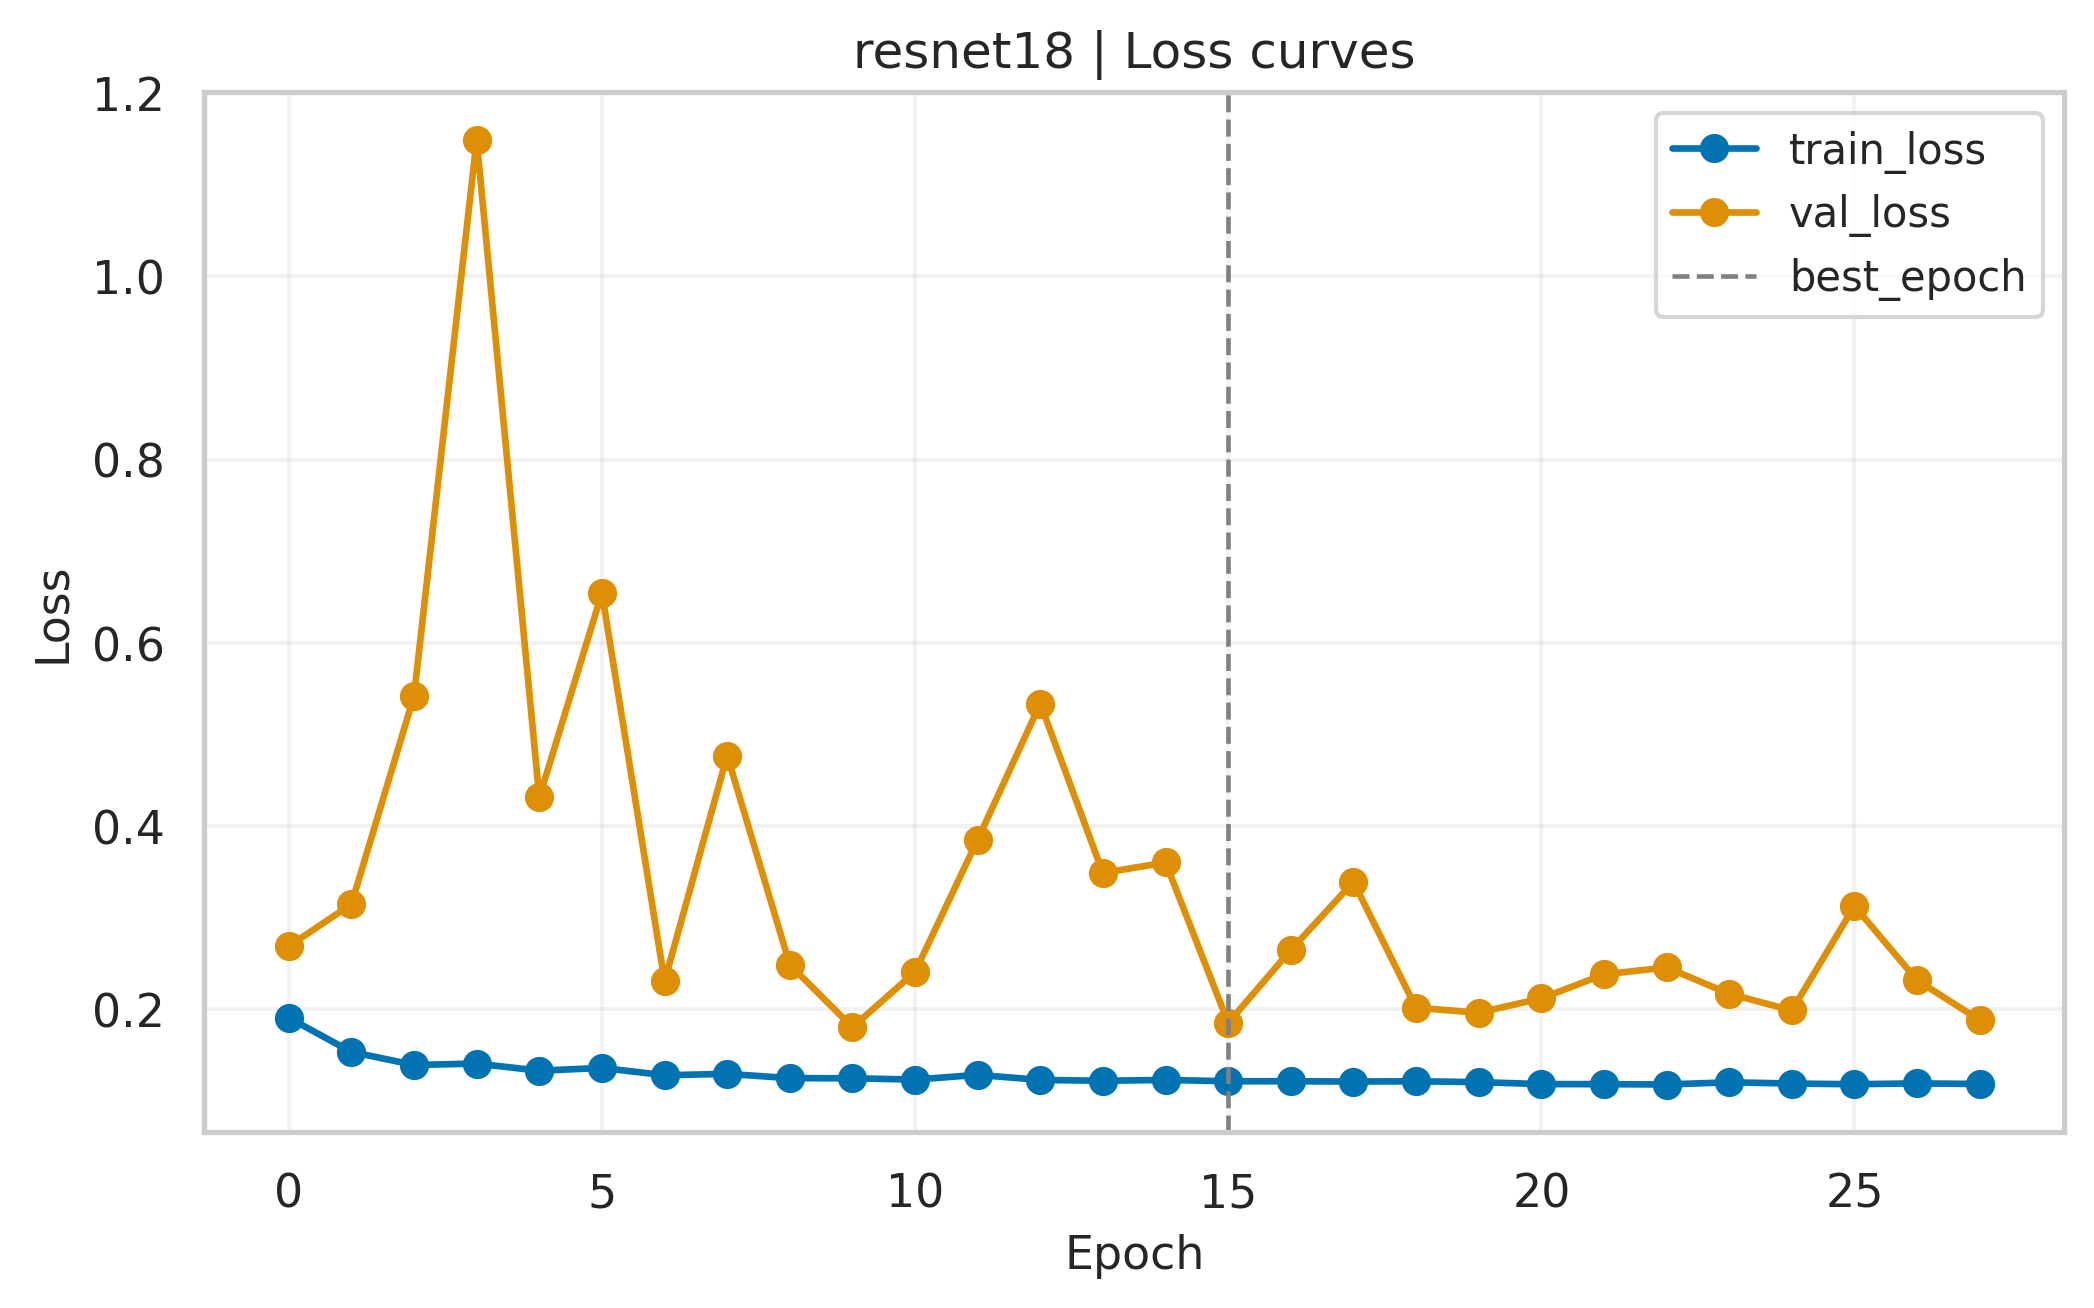

/tmp/ipykernel_98134/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251210-214142_resnet18/plots/train_metrics.pdf


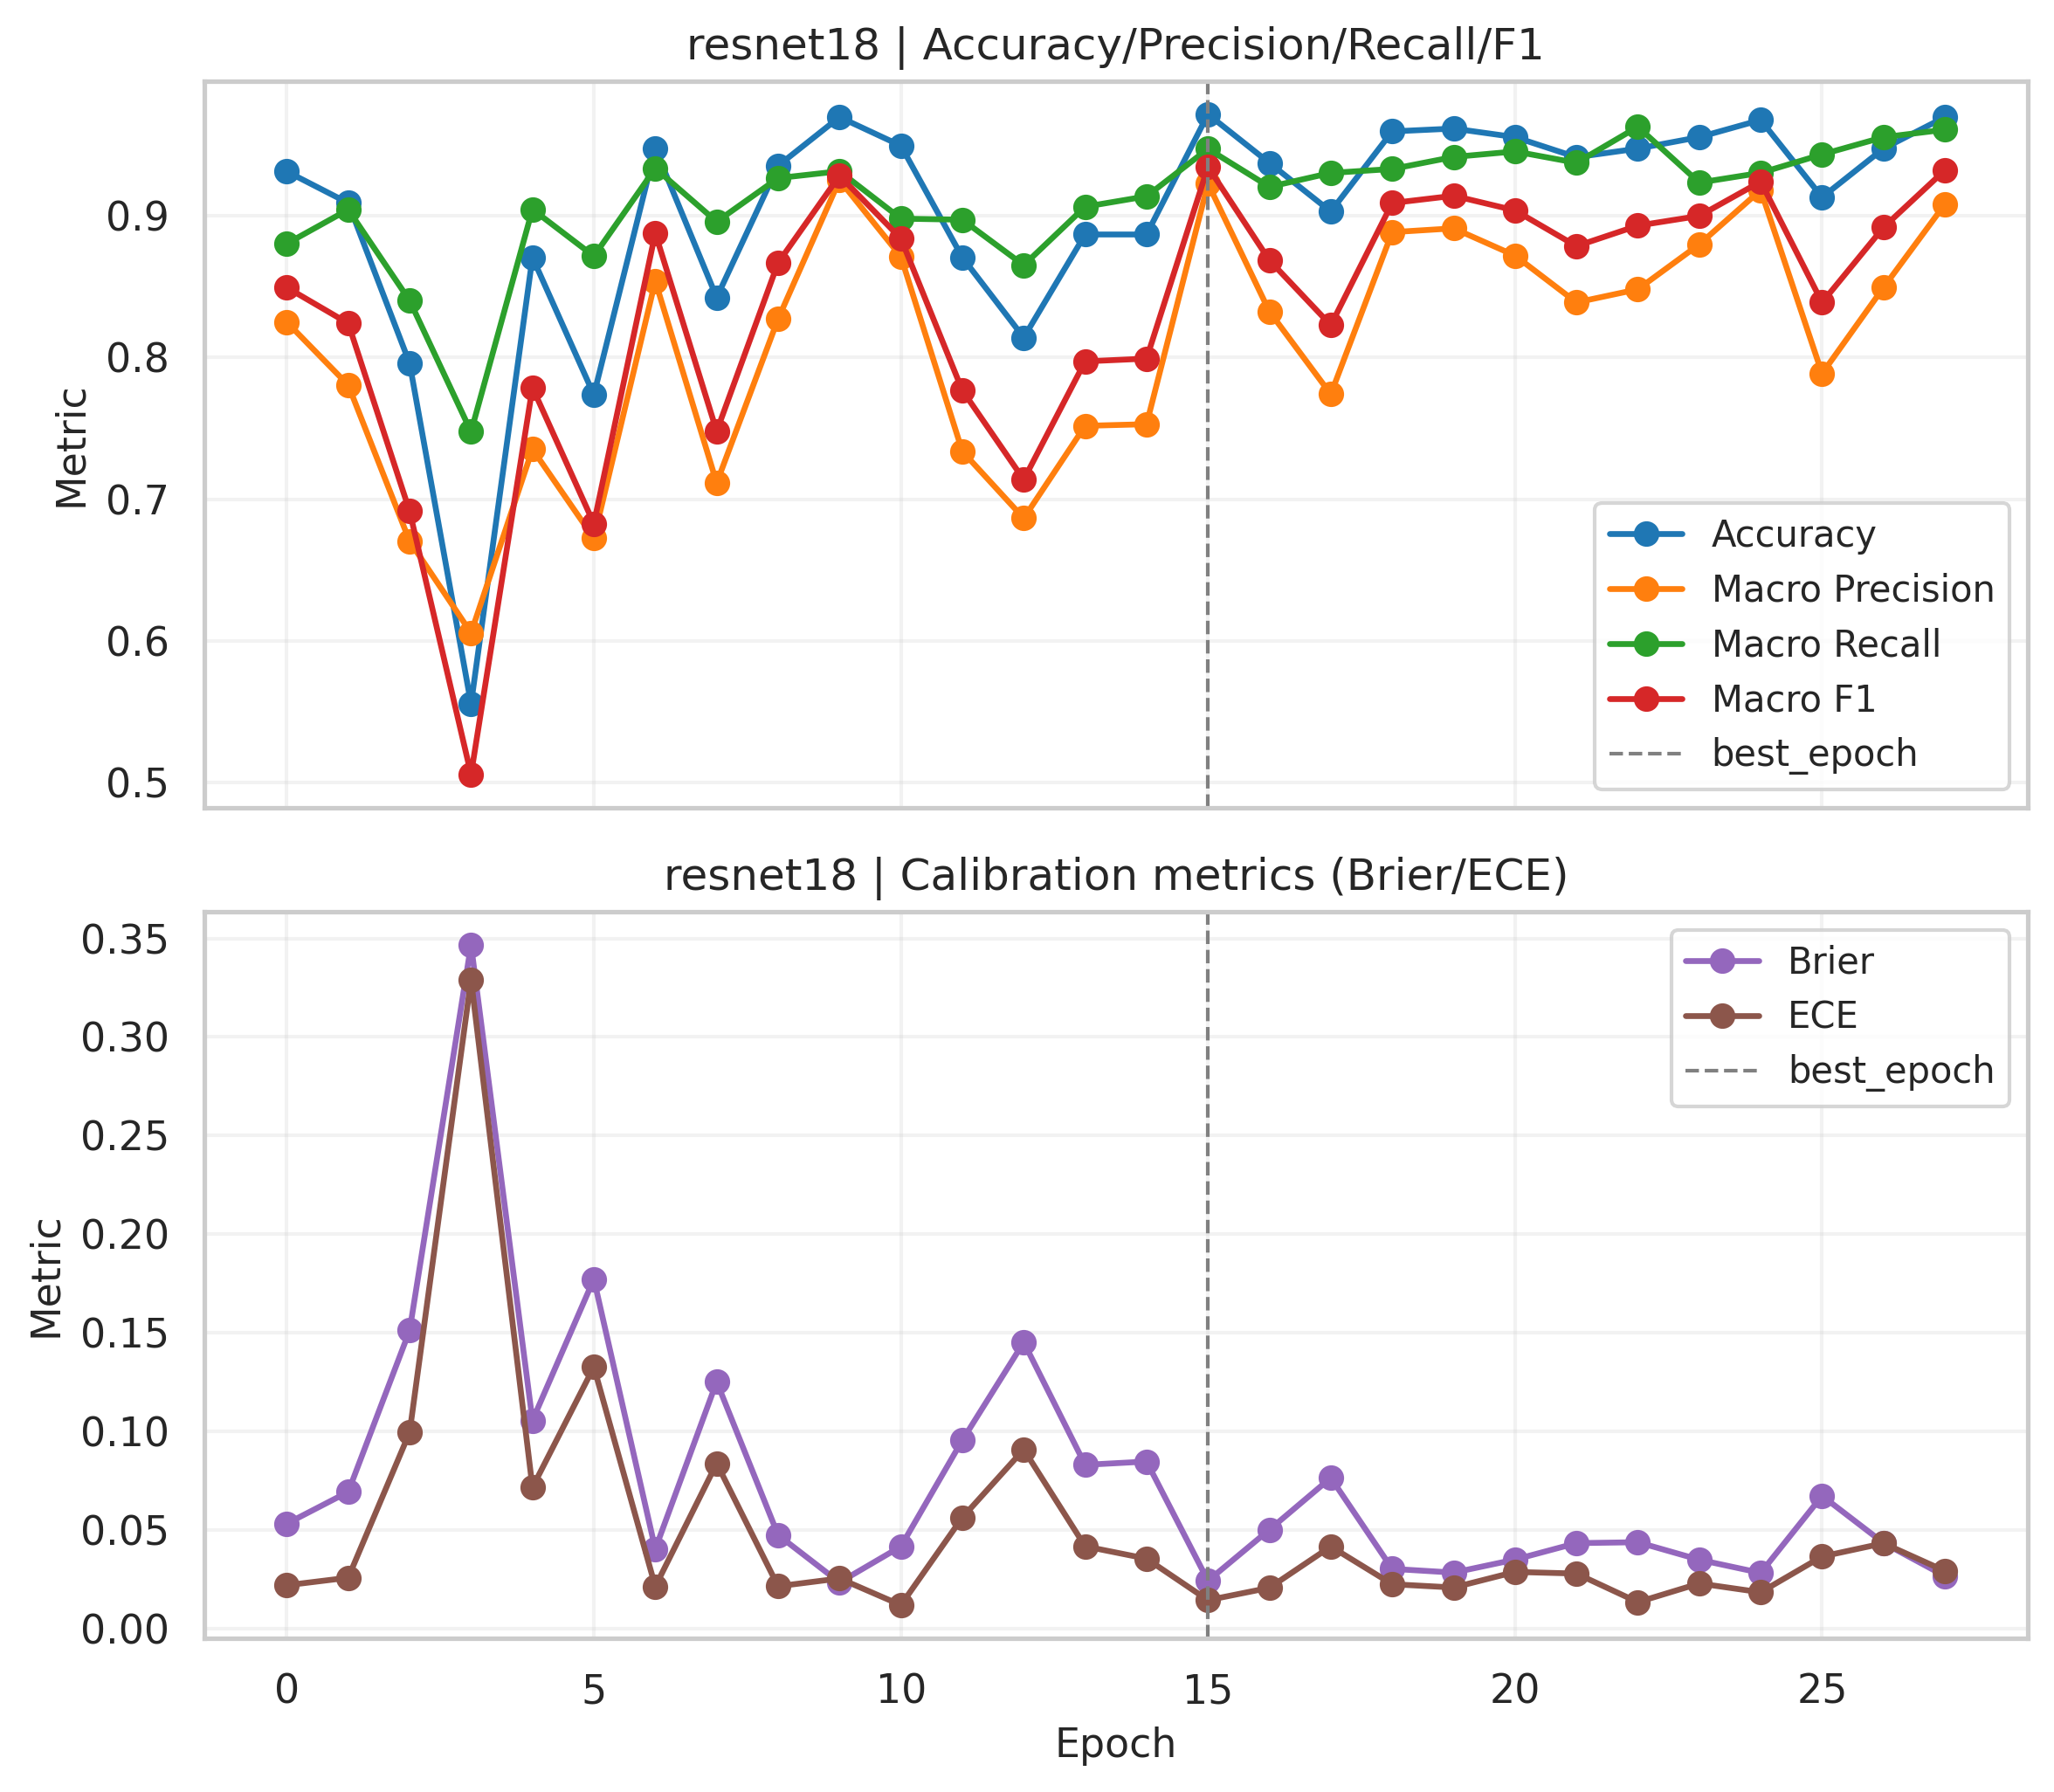

Finished training resnet18 -> training_runs/resampled_20251210-214142_resnet18
Best validation macro_f1: 0.9346


In [4]:
# resnet18 configuration + training
resnet18_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet18', 'batch_size': 64, 'lr': 0.0003, 'dropout': 0.2, 'image_size': 256}}
resnet18_run = run_experiment("resnet18", resnet18_overrides)


2025-12-10 21:47:38,455 | INFO | Epoch 000 | train_loss=0.2005 | val_loss=0.3883 | val_f1=0.763
2025-12-10 21:47:49,752 | INFO | Epoch 001 | train_loss=0.1553 | val_loss=0.3234 | val_f1=0.785
2025-12-10 21:48:02,222 | INFO | Epoch 002 | train_loss=0.1488 | val_loss=0.3643 | val_f1=0.762
2025-12-10 21:48:13,484 | INFO | Epoch 003 | train_loss=0.1450 | val_loss=0.3300 | val_f1=0.815
2025-12-10 21:48:26,192 | INFO | Epoch 004 | train_loss=0.1384 | val_loss=0.5960 | val_f1=0.668
2025-12-10 21:48:38,886 | INFO | Epoch 005 | train_loss=0.1328 | val_loss=0.8871 | val_f1=0.593
2025-12-10 21:48:50,096 | INFO | Epoch 006 | train_loss=0.1309 | val_loss=0.3060 | val_f1=0.831
2025-12-10 21:49:02,741 | INFO | Epoch 007 | train_loss=0.1284 | val_loss=0.6149 | val_f1=0.684
2025-12-10 21:49:14,174 | INFO | Epoch 008 | train_loss=0.1320 | val_loss=0.2535 | val_f1=0.873
2025-12-10 21:49:26,677 | INFO | Epoch 009 | train_loss=0.1307 | val_loss=0.2007 | val_f1=0.918
2025-12-10 21:49:38,124 | INFO | Epoch 0

Saved figure to training_runs/resampled_20251210-214142_resnet34/plots/train_loss_curves.pdf


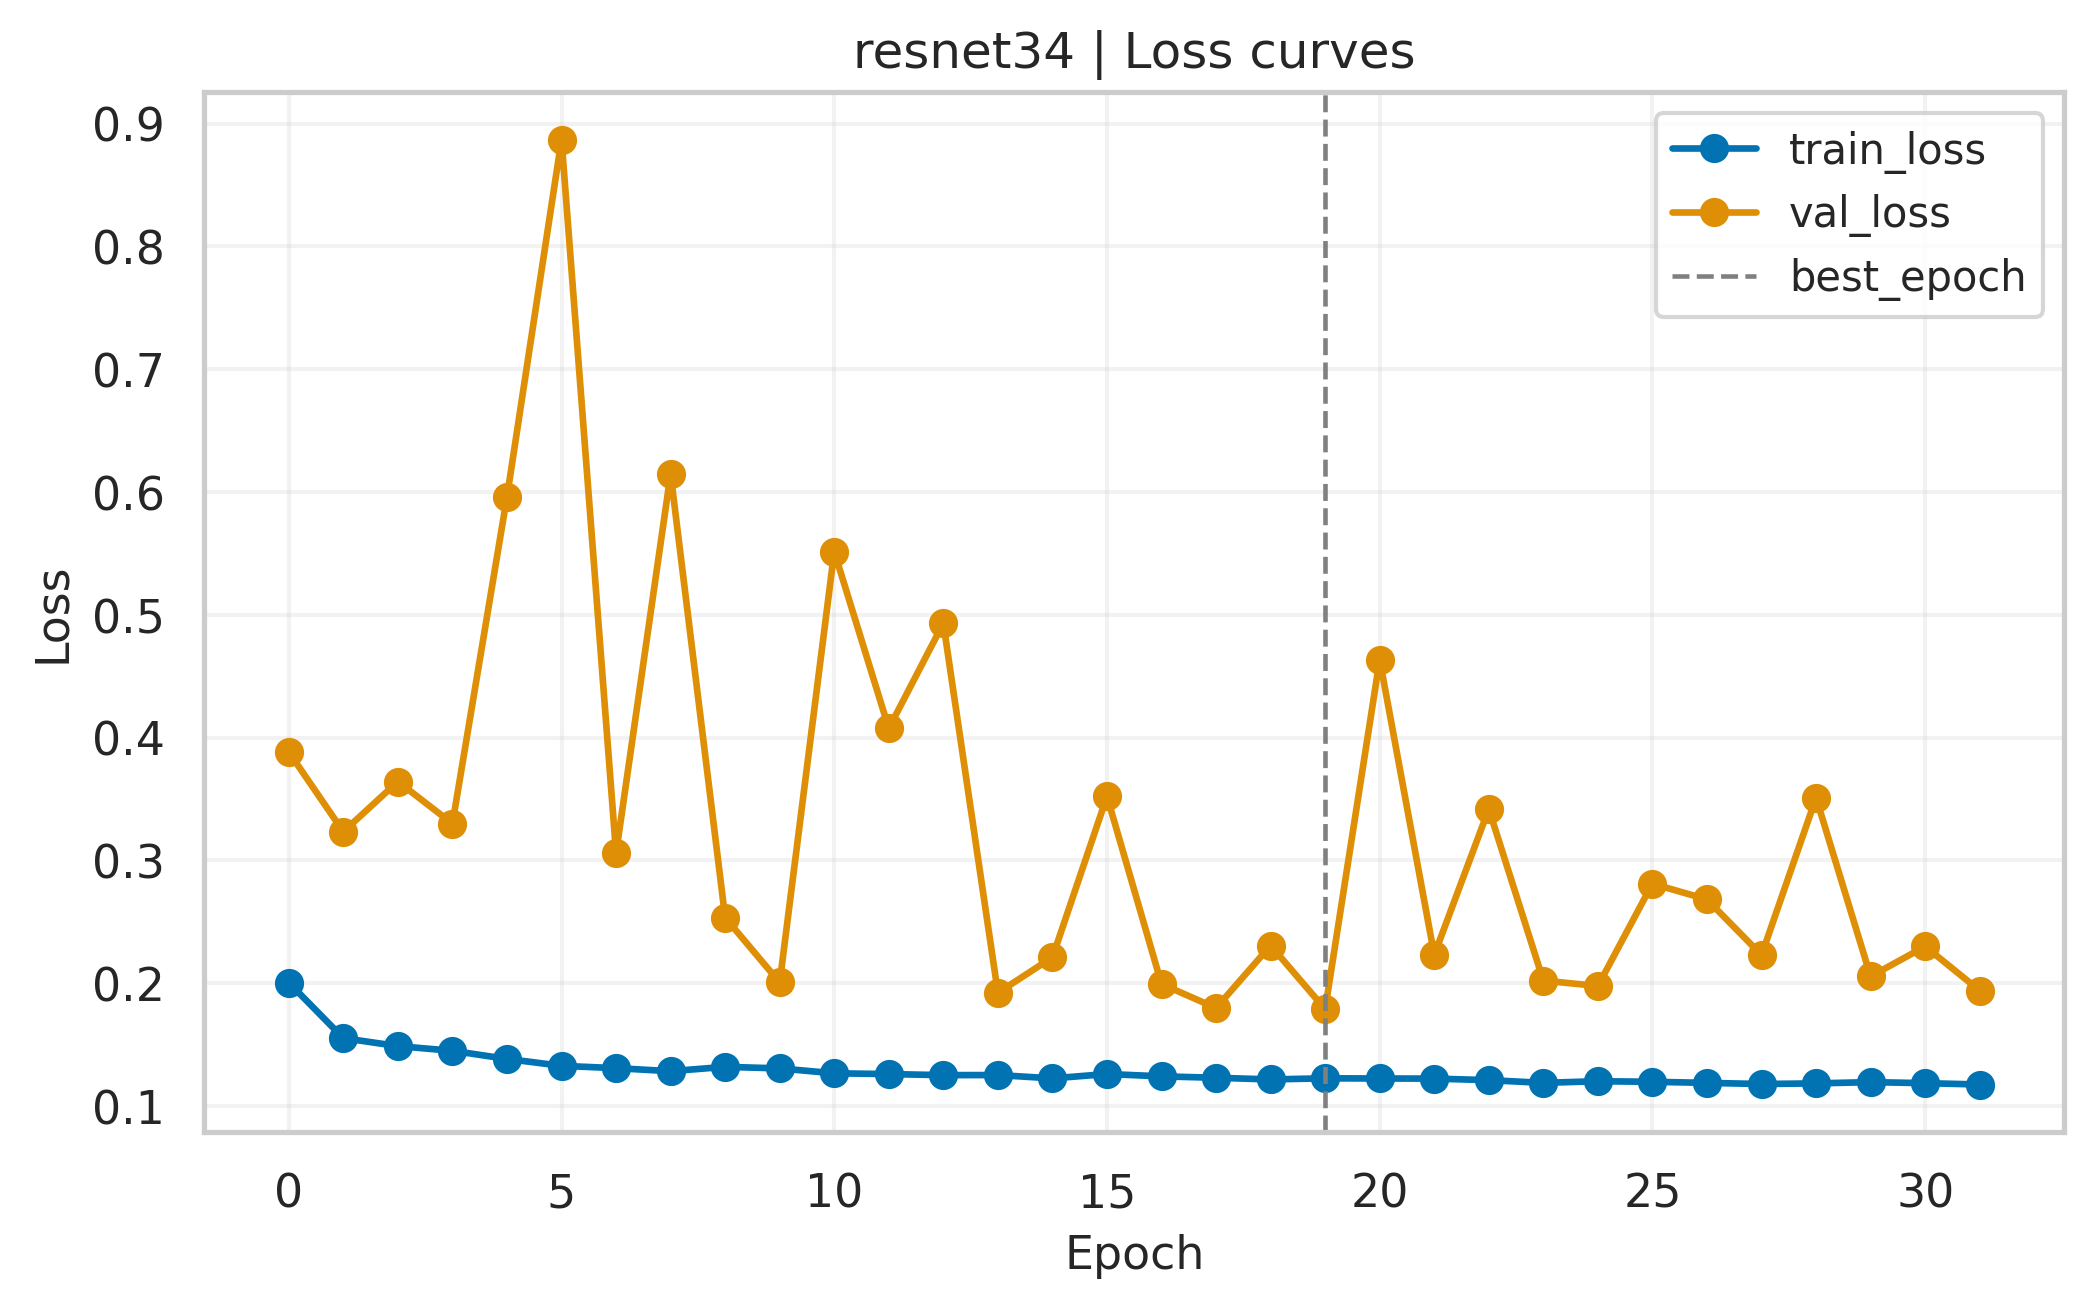

/tmp/ipykernel_98134/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251210-214142_resnet34/plots/train_metrics.pdf


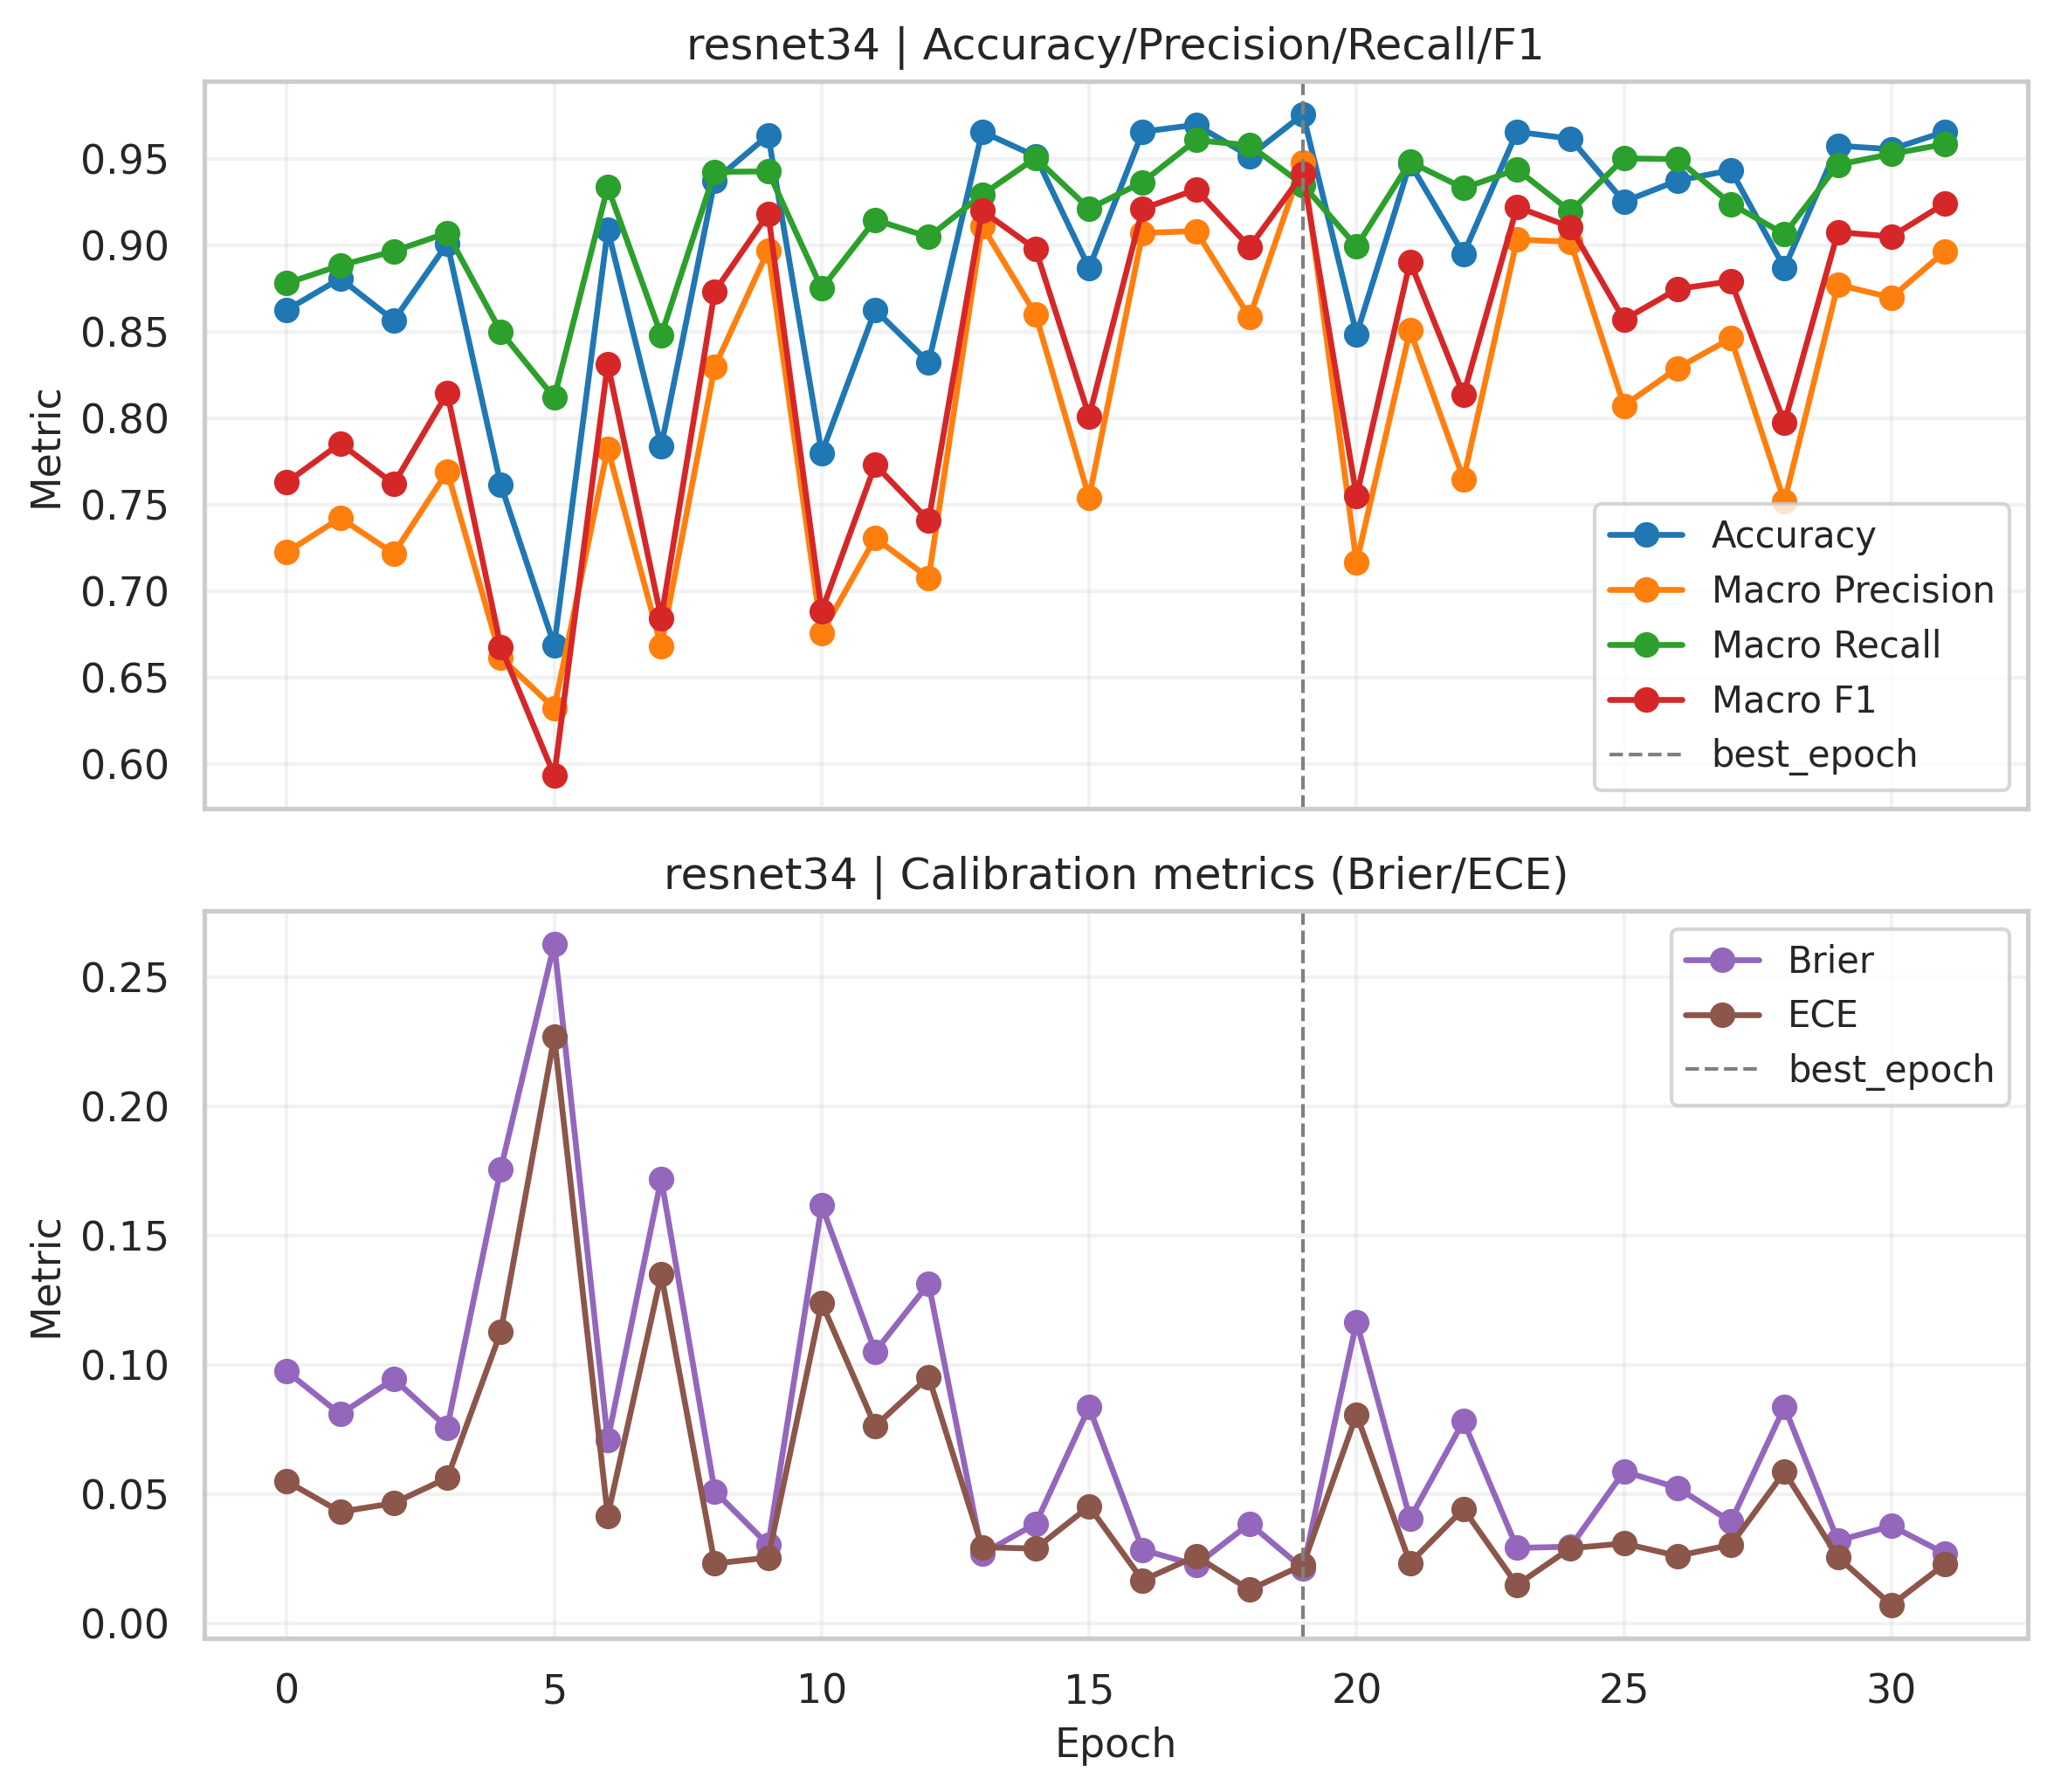

Finished training resnet34 -> training_runs/resampled_20251210-214142_resnet34
Best validation macro_f1: 0.9414


In [5]:
# resnet34 configuration + training
resnet34_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet34', 'batch_size': 48, 'lr': 0.0003, 'dropout': 0.2, 'image_size': 256}}
resnet34_run = run_experiment("resnet34", resnet34_overrides)


2025-12-10 21:54:08,515 | INFO | Epoch 000 | train_loss=0.1949 | val_loss=0.3465 | val_f1=0.815
2025-12-10 21:54:21,411 | INFO | Epoch 001 | train_loss=0.1448 | val_loss=0.2749 | val_f1=0.851
2025-12-10 21:54:35,165 | INFO | Epoch 002 | train_loss=0.1372 | val_loss=0.4637 | val_f1=0.726
2025-12-10 21:54:49,486 | INFO | Epoch 003 | train_loss=0.1300 | val_loss=0.2961 | val_f1=0.828
2025-12-10 21:55:02,708 | INFO | Epoch 004 | train_loss=0.1329 | val_loss=0.2017 | val_f1=0.930
2025-12-10 21:55:17,104 | INFO | Epoch 005 | train_loss=0.1298 | val_loss=0.2754 | val_f1=0.834
2025-12-10 21:55:30,290 | INFO | Epoch 006 | train_loss=0.1253 | val_loss=0.2917 | val_f1=0.847
2025-12-10 21:55:44,617 | INFO | Epoch 007 | train_loss=0.1286 | val_loss=0.1895 | val_f1=0.923
2025-12-10 21:55:57,412 | INFO | Epoch 008 | train_loss=0.1260 | val_loss=0.3075 | val_f1=0.821
2025-12-10 21:56:11,411 | INFO | Epoch 009 | train_loss=0.1237 | val_loss=0.2269 | val_f1=0.875
2025-12-10 21:56:24,351 | INFO | Epoch 0

Saved figure to training_runs/resampled_20251210-214142_resnet50/plots/train_loss_curves.pdf


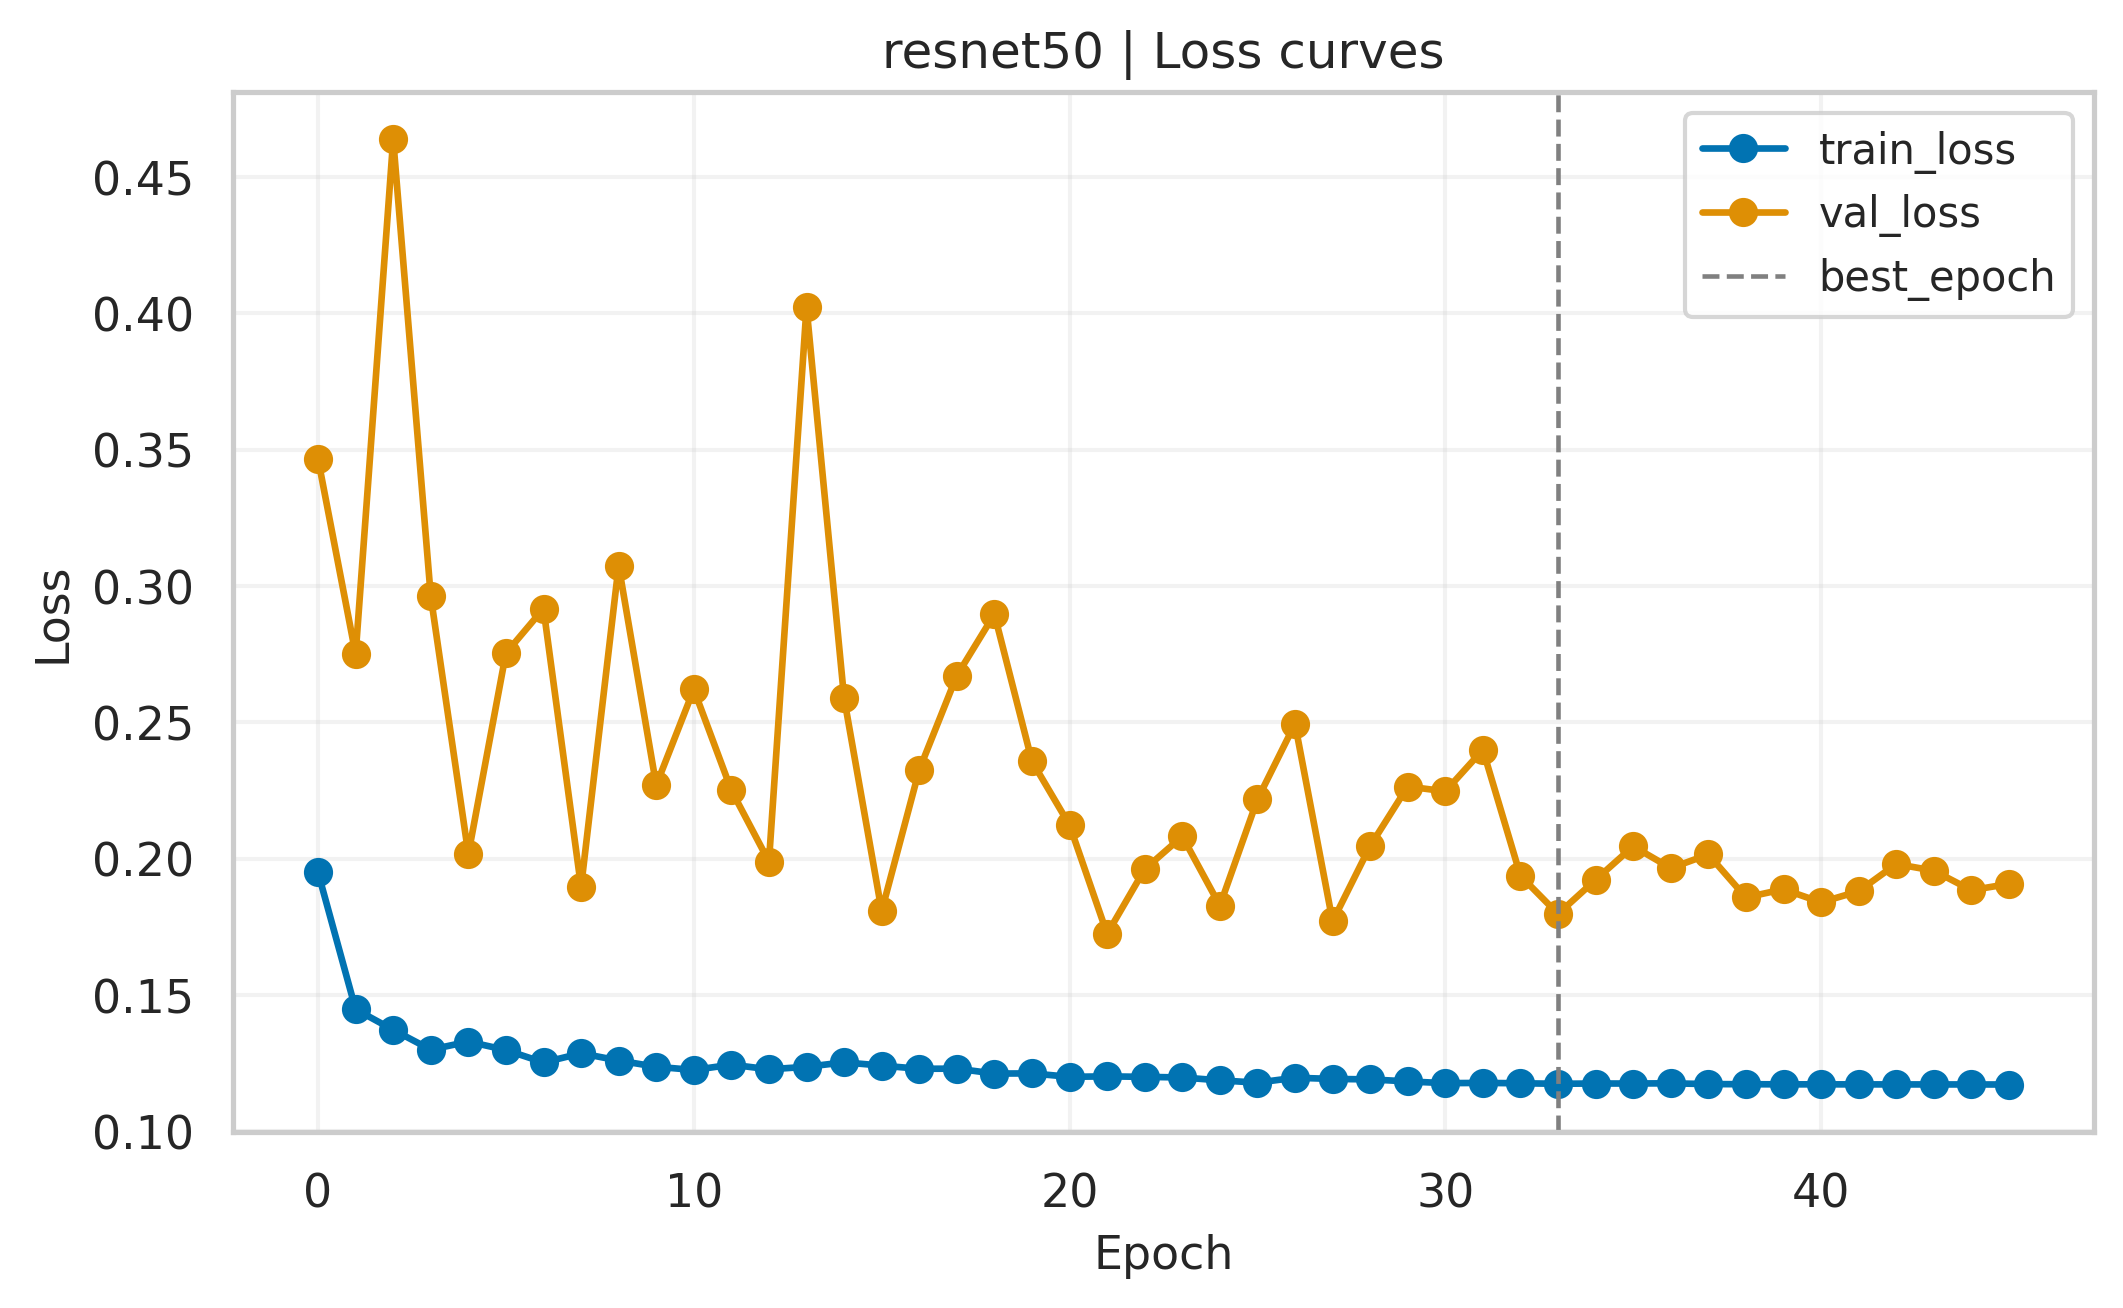

/tmp/ipykernel_98134/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251210-214142_resnet50/plots/train_metrics.pdf


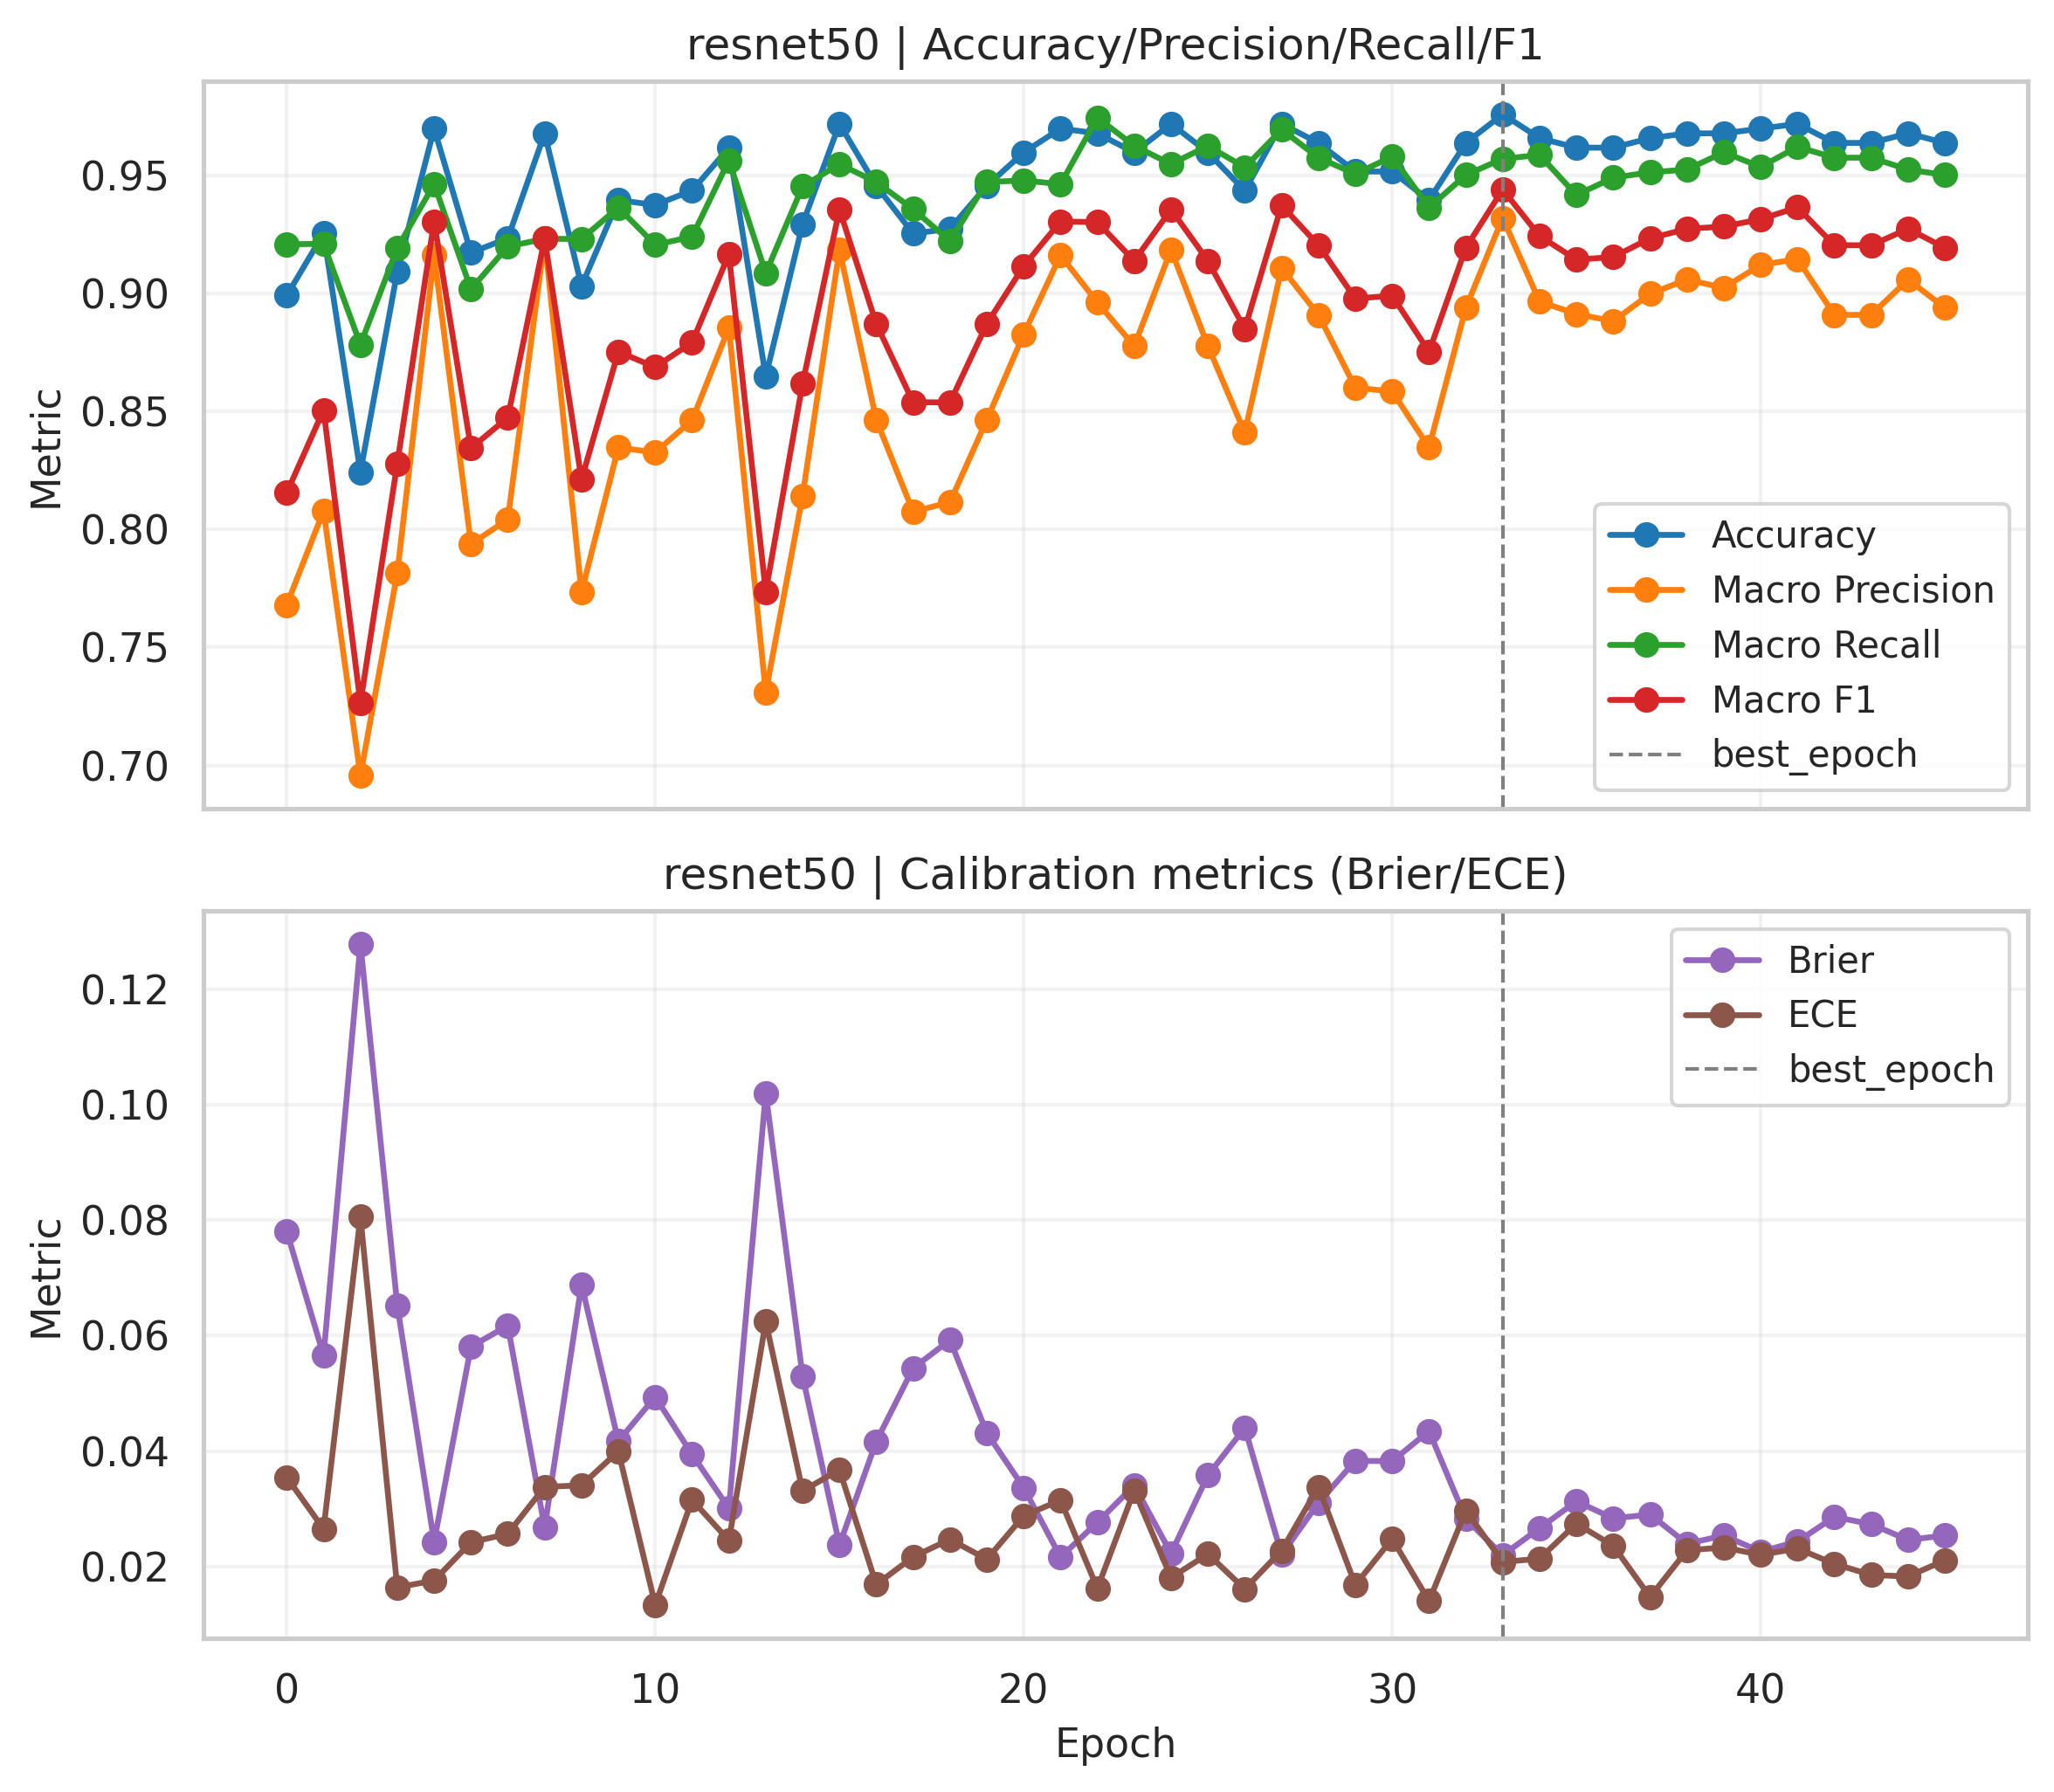

Finished training resnet50 -> training_runs/resampled_20251210-214142_resnet50
Best validation macro_f1: 0.9439


In [6]:
# resnet50 configuration + training
resnet50_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet50', 'batch_size': 32, 'lr': 0.00025, 'dropout': 0.25, 'image_size': 256}}
resnet50_run = run_experiment("resnet50", resnet50_overrides)


2025-12-10 22:04:49,829 | INFO | Epoch 000 | train_loss=0.1913 | val_loss=0.2542 | val_f1=0.847
2025-12-10 22:05:02,140 | INFO | Epoch 001 | train_loss=0.1402 | val_loss=0.2152 | val_f1=0.911
2025-12-10 22:05:15,860 | INFO | Epoch 002 | train_loss=0.1332 | val_loss=0.2329 | val_f1=0.889
2025-12-10 22:05:28,088 | INFO | Epoch 003 | train_loss=0.1255 | val_loss=0.2150 | val_f1=0.901
2025-12-10 22:05:41,492 | INFO | Epoch 004 | train_loss=0.1252 | val_loss=0.2902 | val_f1=0.827
2025-12-10 22:05:54,831 | INFO | Epoch 005 | train_loss=0.1256 | val_loss=0.1887 | val_f1=0.919
2025-12-10 22:06:06,922 | INFO | Epoch 006 | train_loss=0.1234 | val_loss=0.2306 | val_f1=0.895
2025-12-10 22:06:20,251 | INFO | Epoch 007 | train_loss=0.1213 | val_loss=0.2879 | val_f1=0.849
2025-12-10 22:06:32,300 | INFO | Epoch 008 | train_loss=0.1209 | val_loss=0.2373 | val_f1=0.872
2025-12-10 22:06:45,597 | INFO | Epoch 009 | train_loss=0.1220 | val_loss=0.2620 | val_f1=0.865
2025-12-10 22:06:58,032 | INFO | Epoch 0

Saved figure to training_runs/resampled_20251210-214142_efficientnet_b1/plots/train_loss_curves.pdf


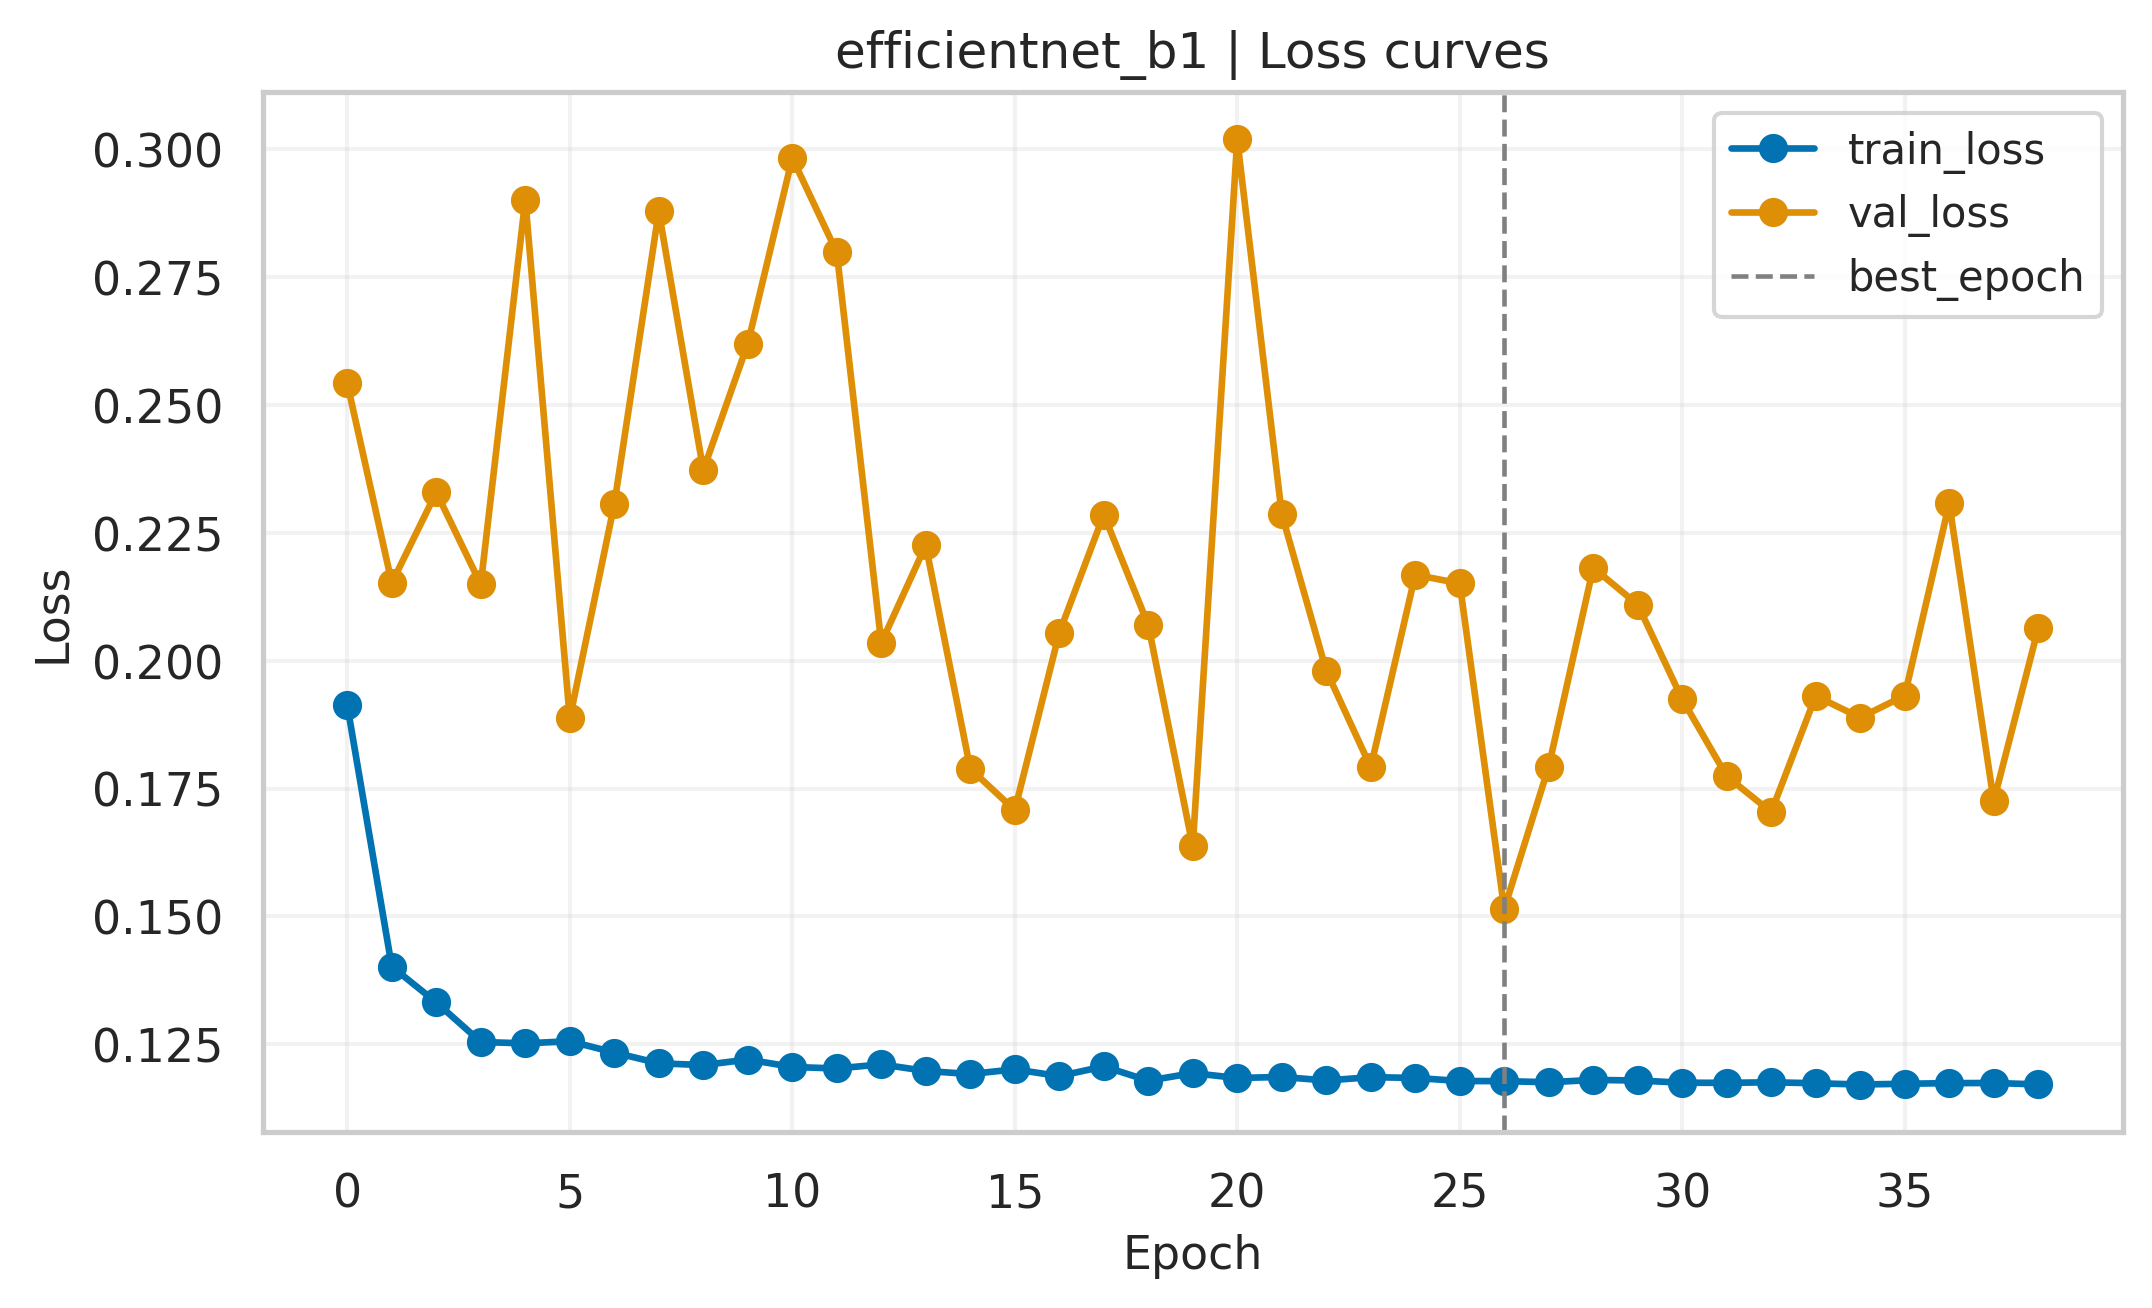

/tmp/ipykernel_98134/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251210-214142_efficientnet_b1/plots/train_metrics.pdf


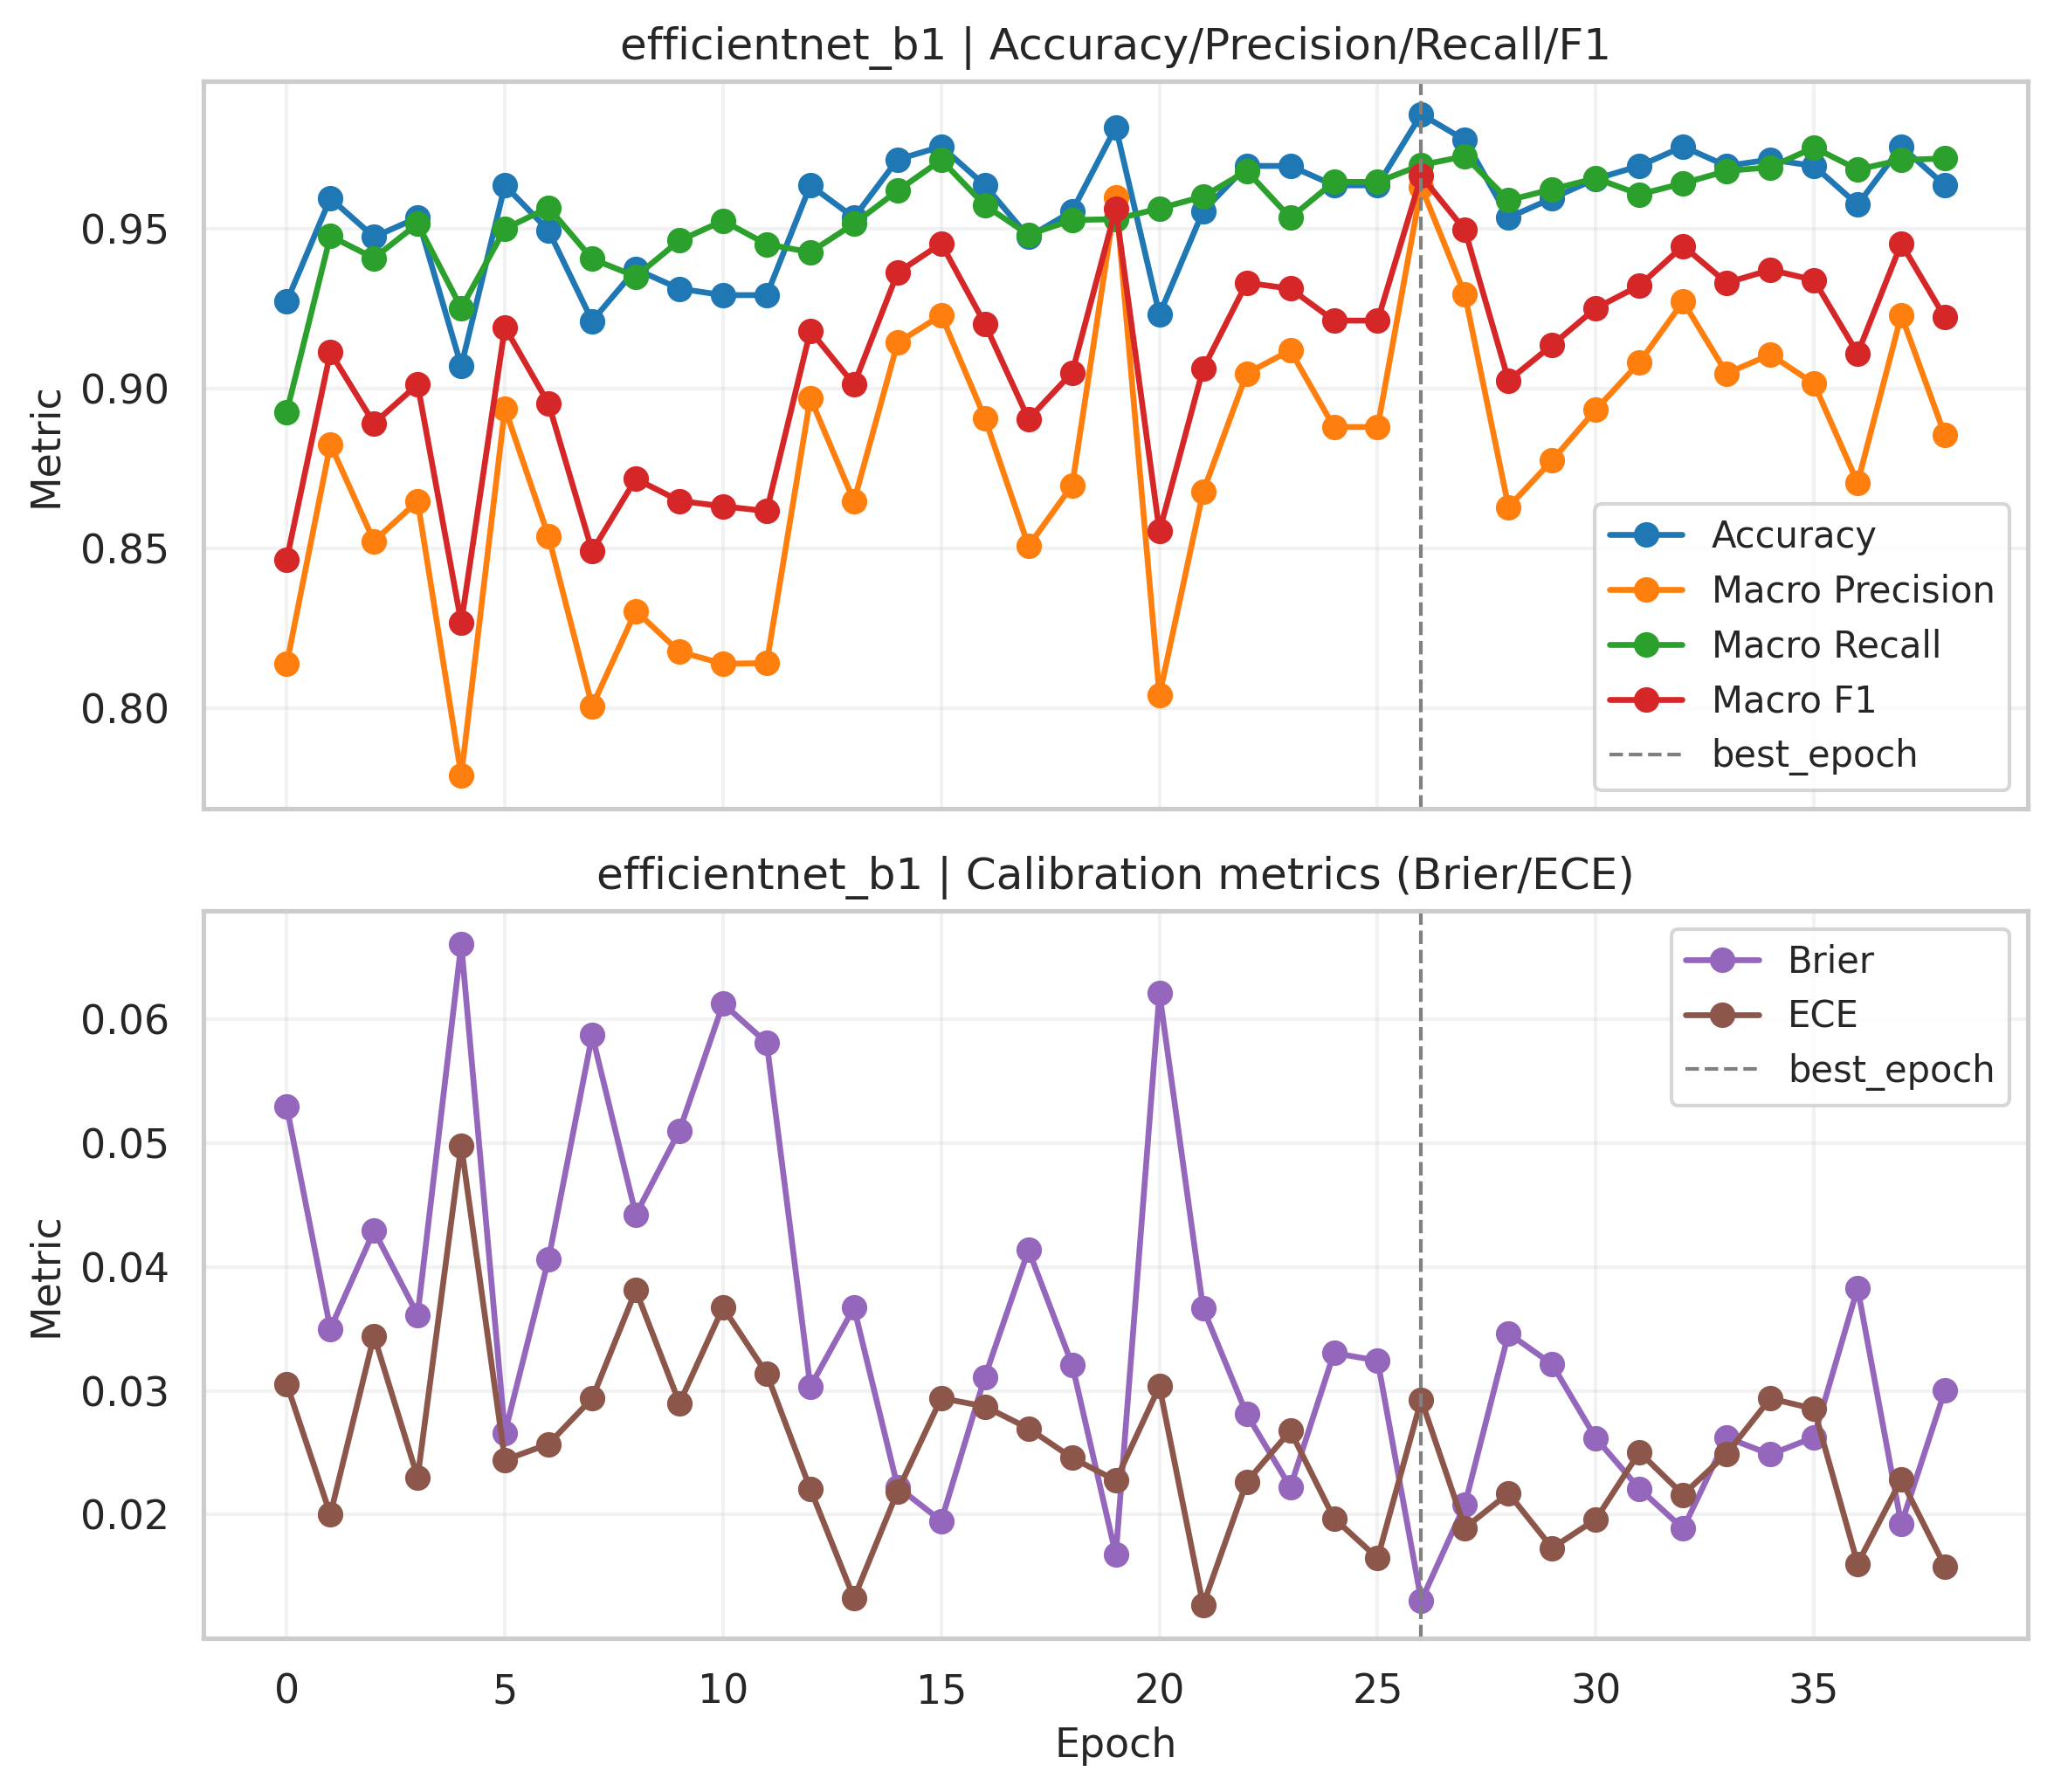

Finished training efficientnet_b1 -> training_runs/resampled_20251210-214142_efficientnet_b1
Best validation macro_f1: 0.9666


In [7]:
# efficientnet_b1 configuration + training
efficientnet_b1_overrides = {**BASE_OVERRIDES, **{'model_name': 'efficientnet_b1', 'batch_size': 48, 'lr': 0.0003, 'dropout': 0.3, 'image_size': 240}}
efficientnet_b1_run = run_experiment("efficientnet_b1", efficientnet_b1_overrides)


2025-12-10 22:13:24,211 | INFO | Epoch 000 | train_loss=0.1839 | val_loss=0.3016 | val_f1=0.825
2025-12-10 22:13:39,803 | INFO | Epoch 001 | train_loss=0.1375 | val_loss=0.4103 | val_f1=0.788
2025-12-10 22:13:56,866 | INFO | Epoch 002 | train_loss=0.1324 | val_loss=0.1945 | val_f1=0.910
2025-12-10 22:14:12,506 | INFO | Epoch 003 | train_loss=0.1269 | val_loss=0.3862 | val_f1=0.809
2025-12-10 22:14:29,552 | INFO | Epoch 004 | train_loss=0.1239 | val_loss=0.1930 | val_f1=0.937
2025-12-10 22:14:45,359 | INFO | Epoch 005 | train_loss=0.1235 | val_loss=0.3420 | val_f1=0.824
2025-12-10 22:15:00,837 | INFO | Epoch 006 | train_loss=0.1235 | val_loss=0.3626 | val_f1=0.819
2025-12-10 22:15:18,176 | INFO | Epoch 007 | train_loss=0.1244 | val_loss=0.1775 | val_f1=0.934
2025-12-10 22:15:34,024 | INFO | Epoch 008 | train_loss=0.1235 | val_loss=0.3602 | val_f1=0.834
2025-12-10 22:15:51,185 | INFO | Epoch 009 | train_loss=0.1205 | val_loss=0.1968 | val_f1=0.917
2025-12-10 22:16:06,875 | INFO | Epoch 0

Saved figure to training_runs/resampled_20251210-214142_efficientnet_b2/plots/train_loss_curves.pdf


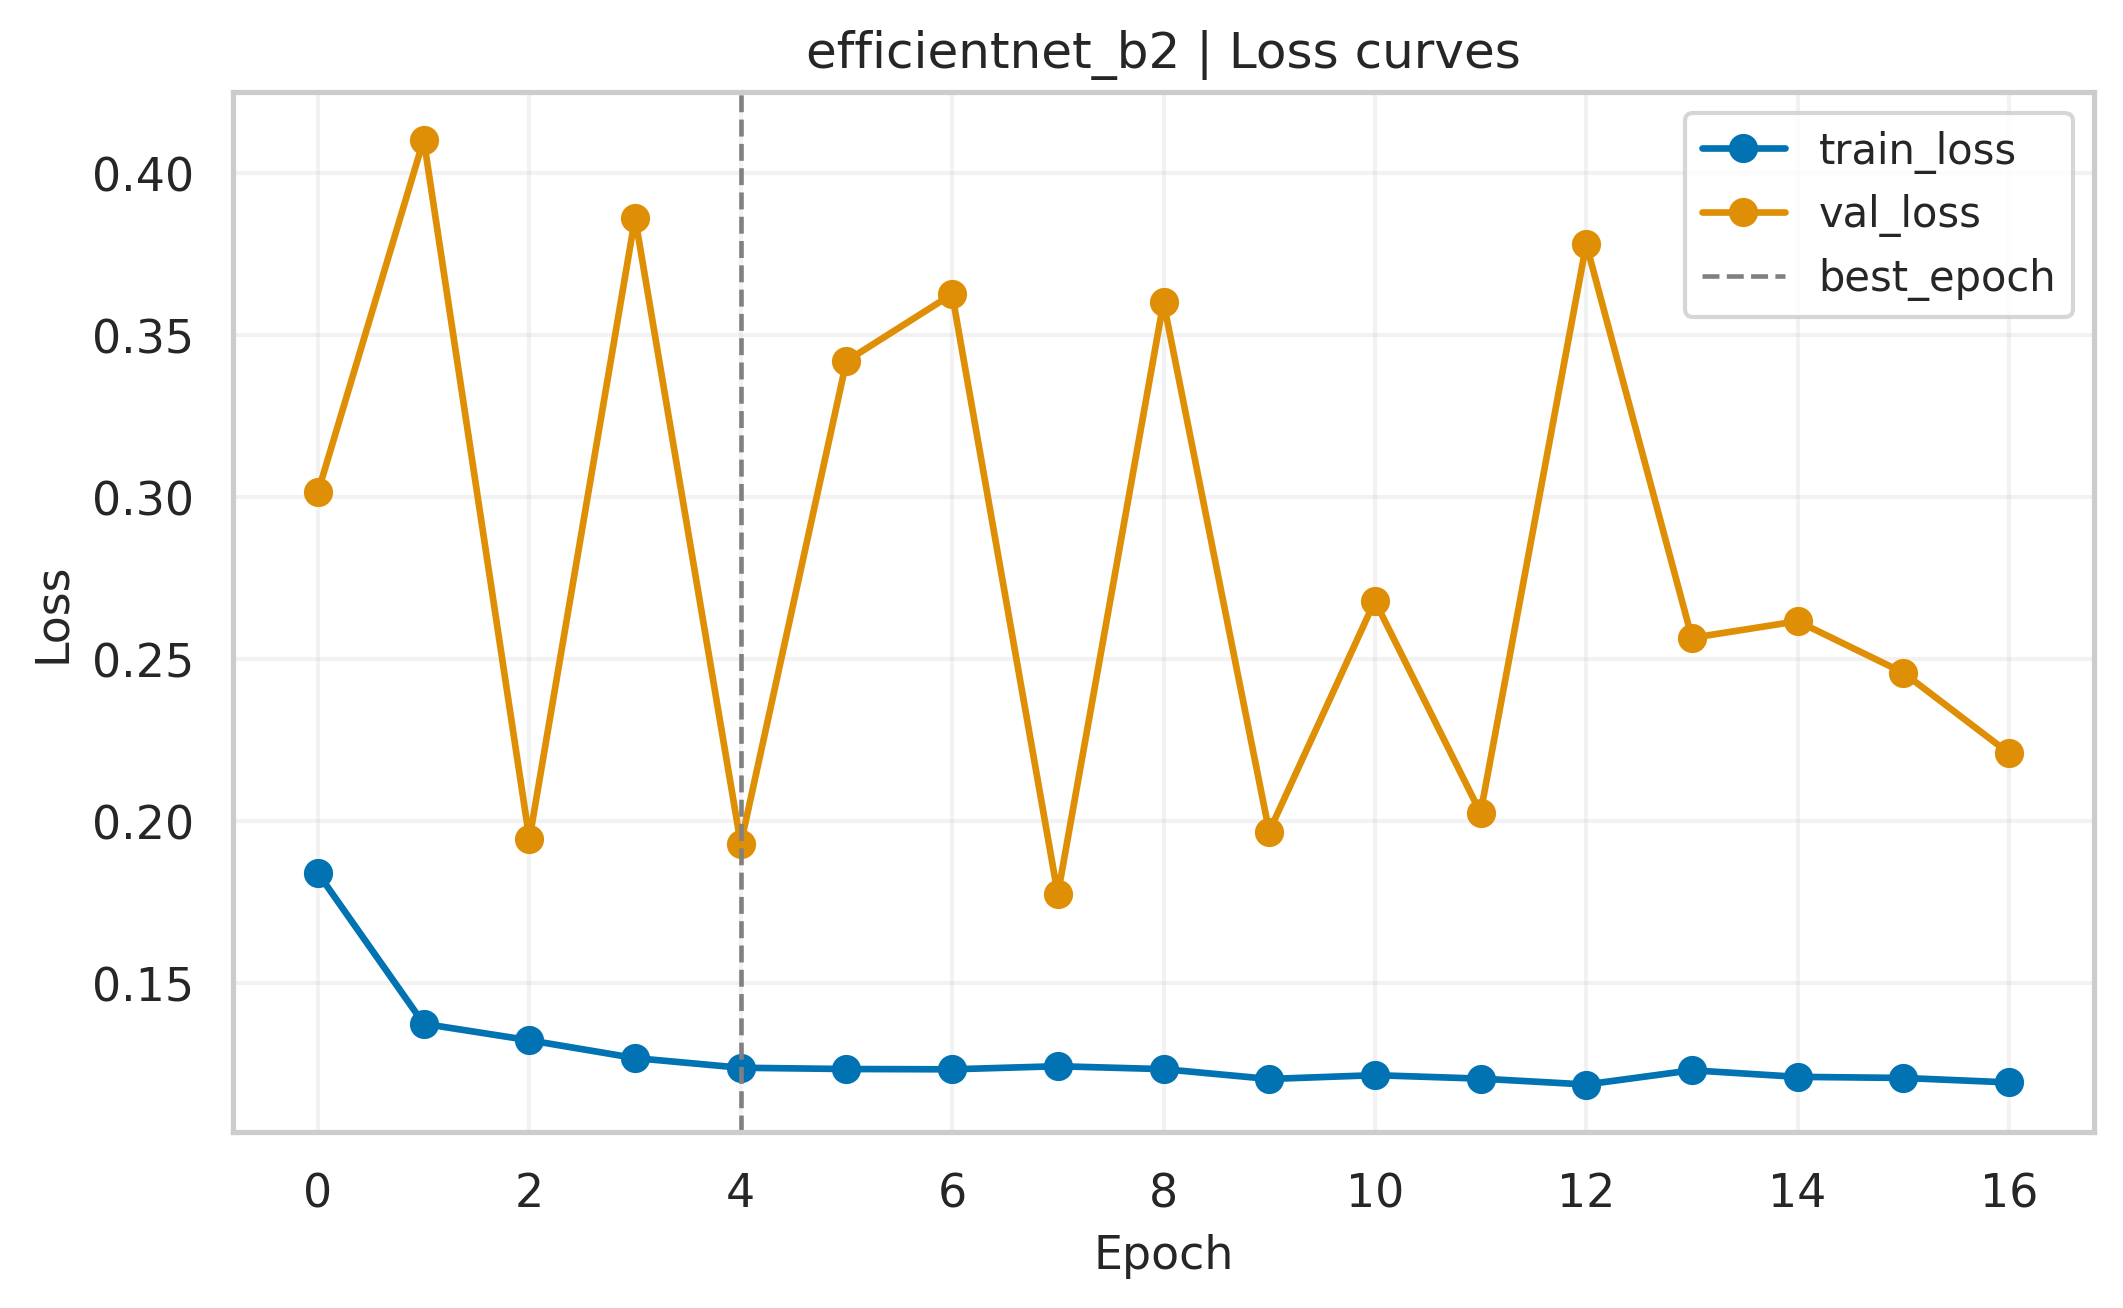

/tmp/ipykernel_98134/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251210-214142_efficientnet_b2/plots/train_metrics.pdf


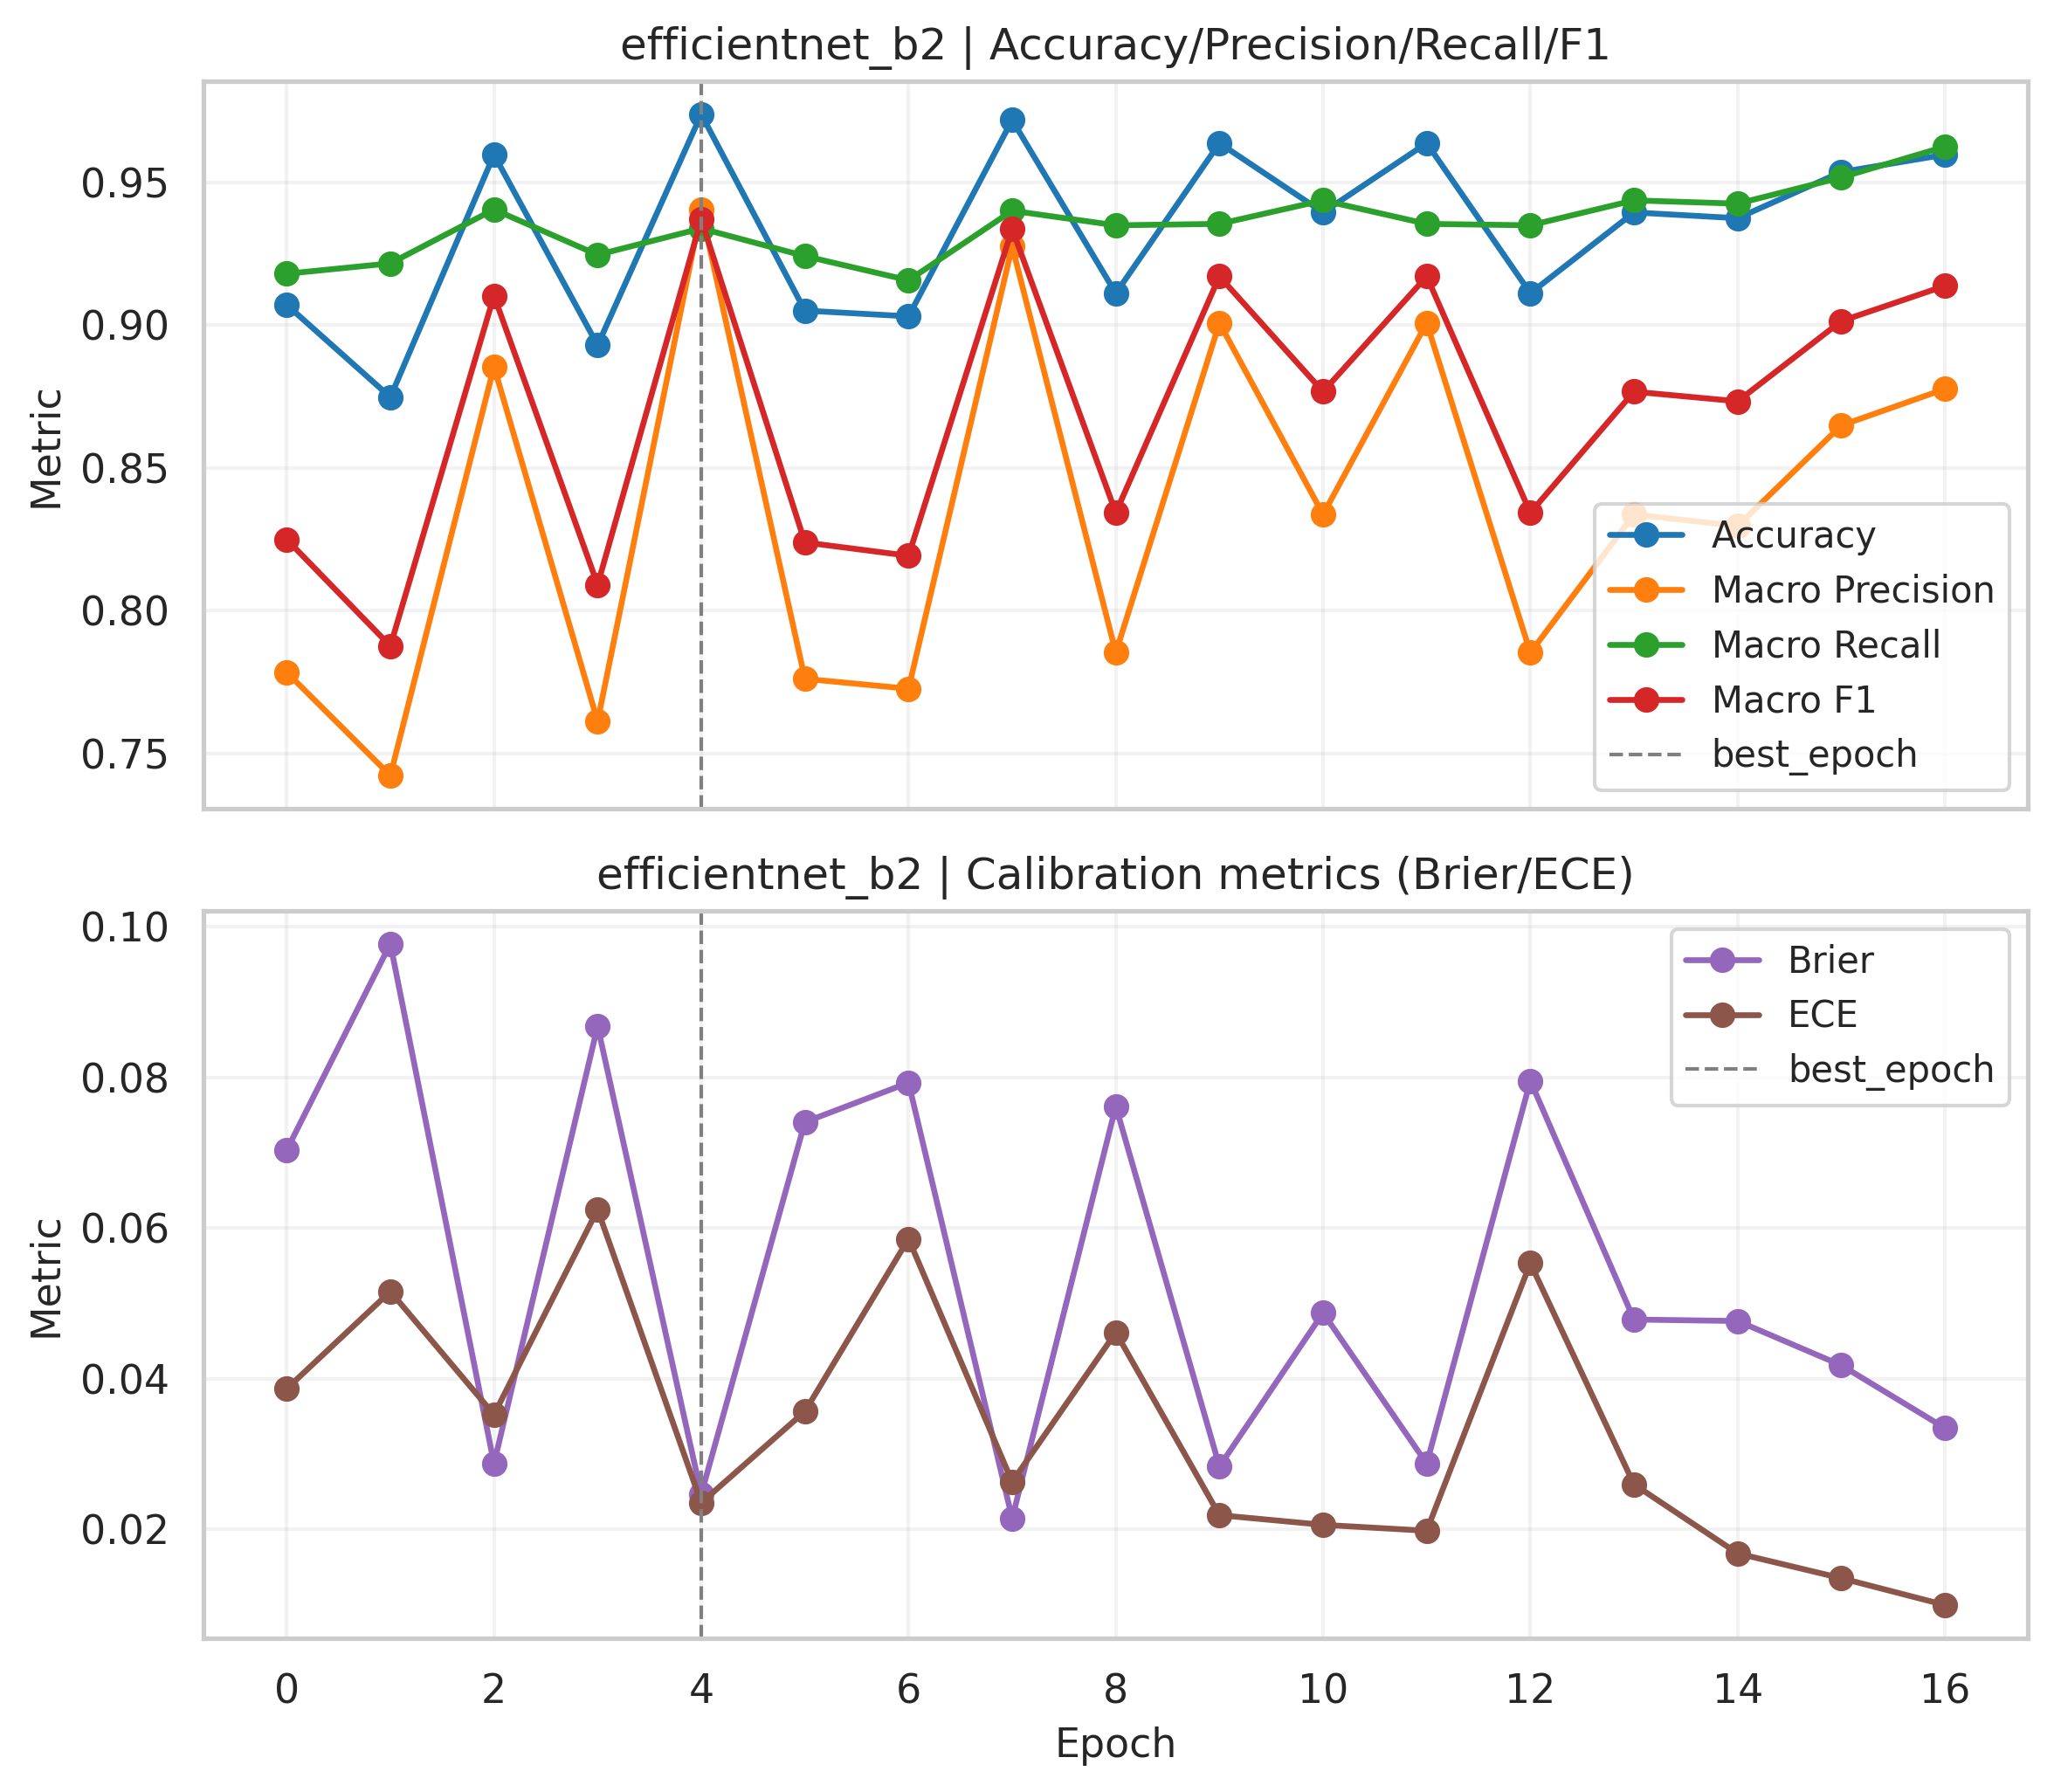

Finished training efficientnet_b2 -> training_runs/resampled_20251210-214142_efficientnet_b2
Best validation macro_f1: 0.9370


In [8]:
# efficientnet_b2 configuration + training
efficientnet_b2_overrides = {**BASE_OVERRIDES, **{'model_name': 'efficientnet_b2', 'batch_size': 36, 'lr': 0.0003, 'dropout': 0.3, 'image_size': 260}}
efficientnet_b2_run = run_experiment("efficientnet_b2", efficientnet_b2_overrides)


2025-12-10 22:18:07,875 | INFO | Epoch 000 | train_loss=0.2241 | val_loss=0.4077 | val_f1=0.764
2025-12-10 22:18:22,949 | INFO | Epoch 001 | train_loss=0.1877 | val_loss=0.5514 | val_f1=0.669
2025-12-10 22:18:39,334 | INFO | Epoch 002 | train_loss=0.1629 | val_loss=0.4009 | val_f1=0.685
2025-12-10 22:18:54,255 | INFO | Epoch 003 | train_loss=0.1445 | val_loss=0.1985 | val_f1=0.909
2025-12-10 22:19:10,610 | INFO | Epoch 004 | train_loss=0.1455 | val_loss=0.2052 | val_f1=0.913
2025-12-10 22:19:25,778 | INFO | Epoch 005 | train_loss=0.1468 | val_loss=0.3274 | val_f1=0.812
2025-12-10 22:19:42,028 | INFO | Epoch 006 | train_loss=0.1498 | val_loss=0.1846 | val_f1=0.926
2025-12-10 22:19:57,024 | INFO | Epoch 007 | train_loss=0.1465 | val_loss=0.2733 | val_f1=0.855
2025-12-10 22:20:13,262 | INFO | Epoch 008 | train_loss=0.1405 | val_loss=0.3057 | val_f1=0.846
2025-12-10 22:20:28,290 | INFO | Epoch 009 | train_loss=0.1381 | val_loss=0.1906 | val_f1=0.926
2025-12-10 22:20:44,684 | INFO | Epoch 0

Saved figure to training_runs/resampled_20251210-214142_convnext_tiny/plots/train_loss_curves.pdf


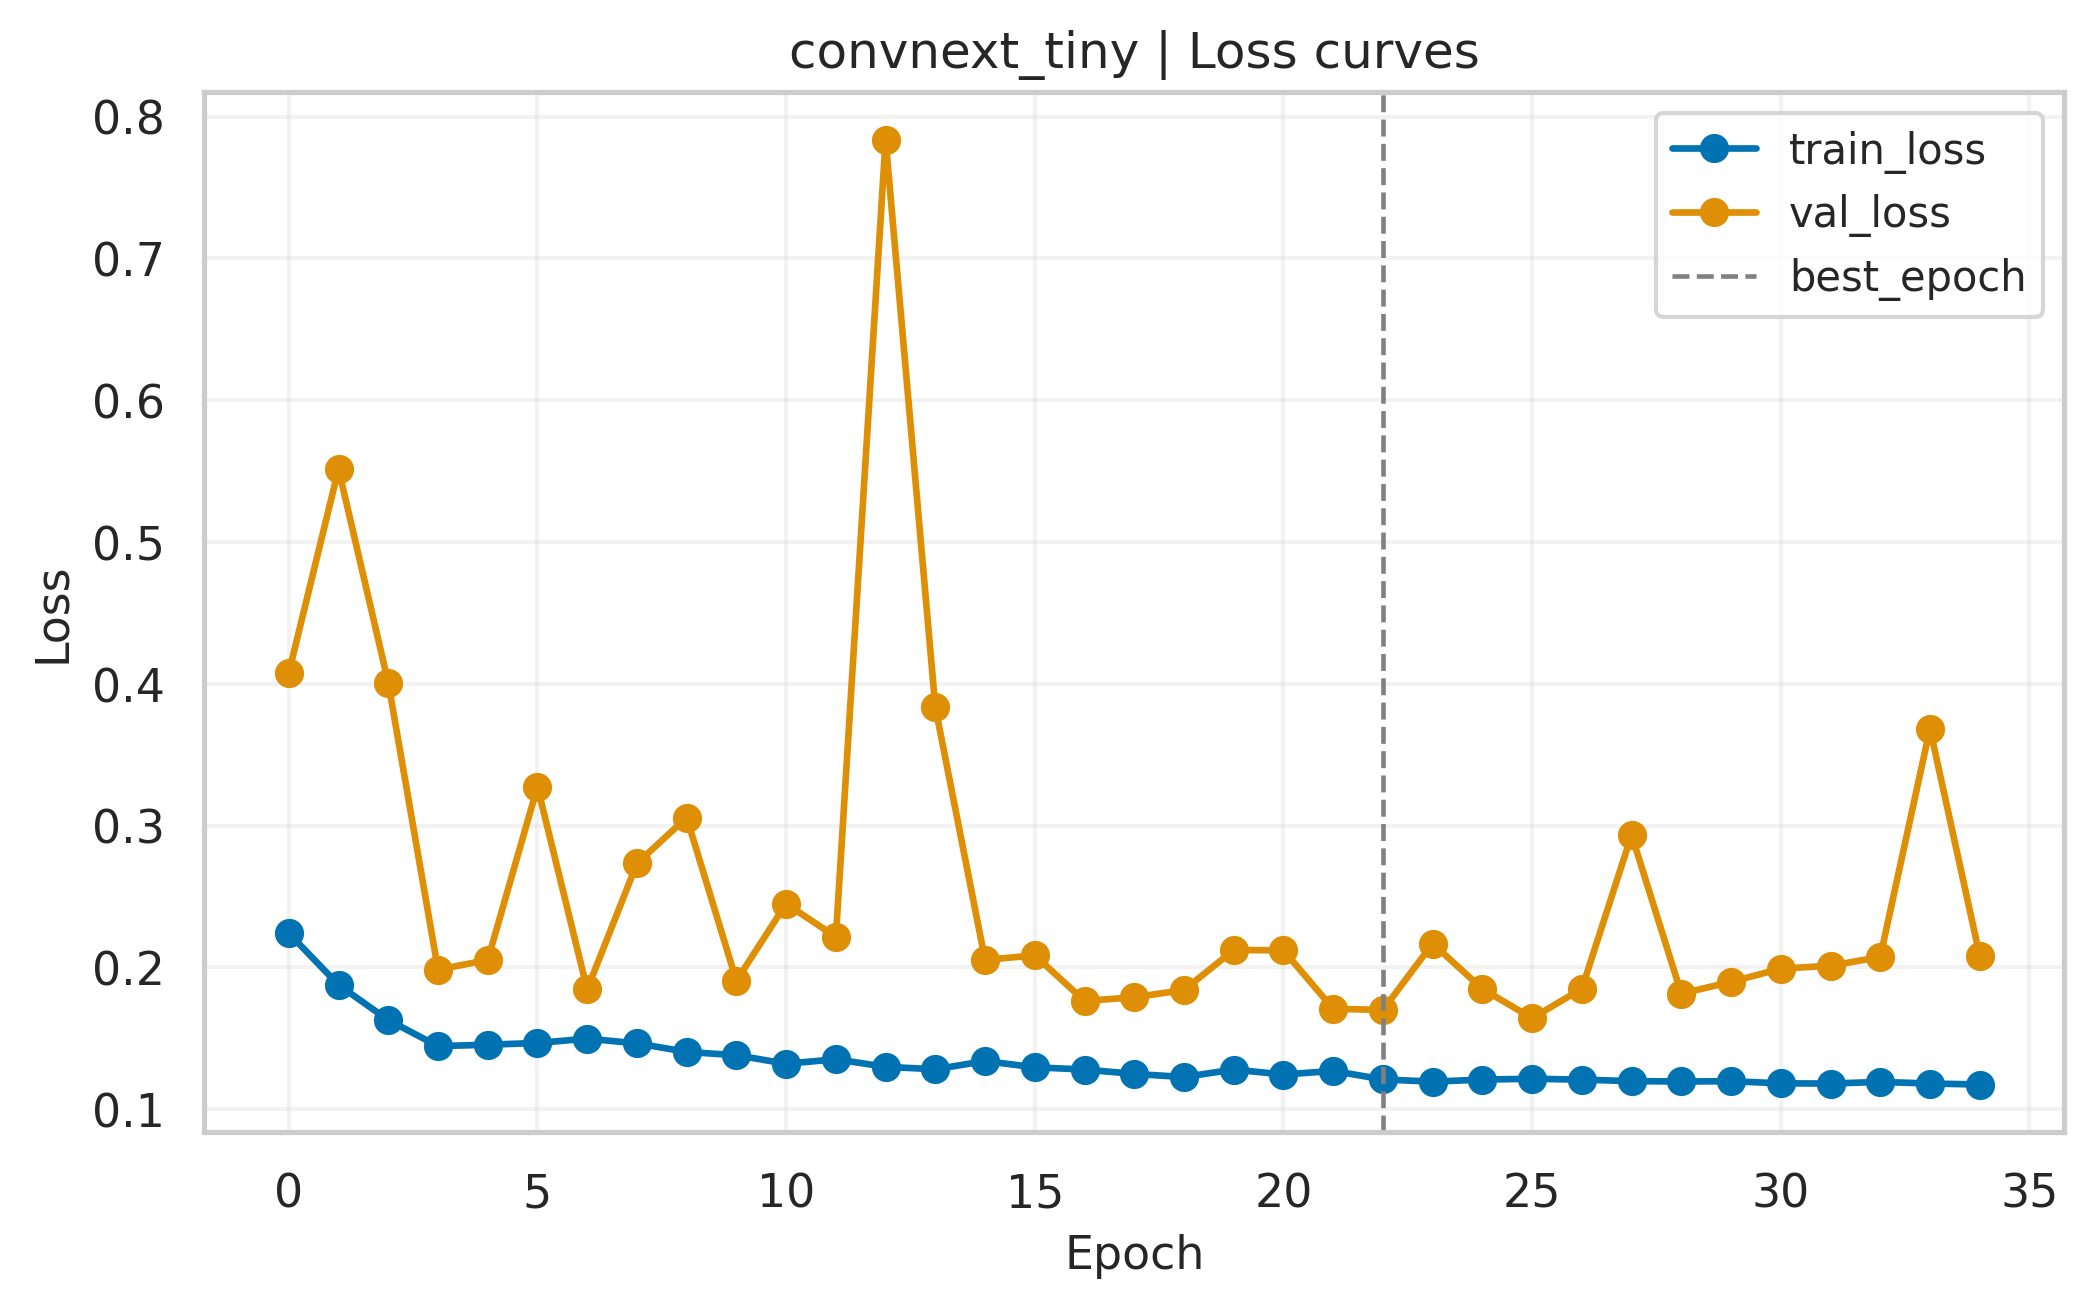

/tmp/ipykernel_98134/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251210-214142_convnext_tiny/plots/train_metrics.pdf


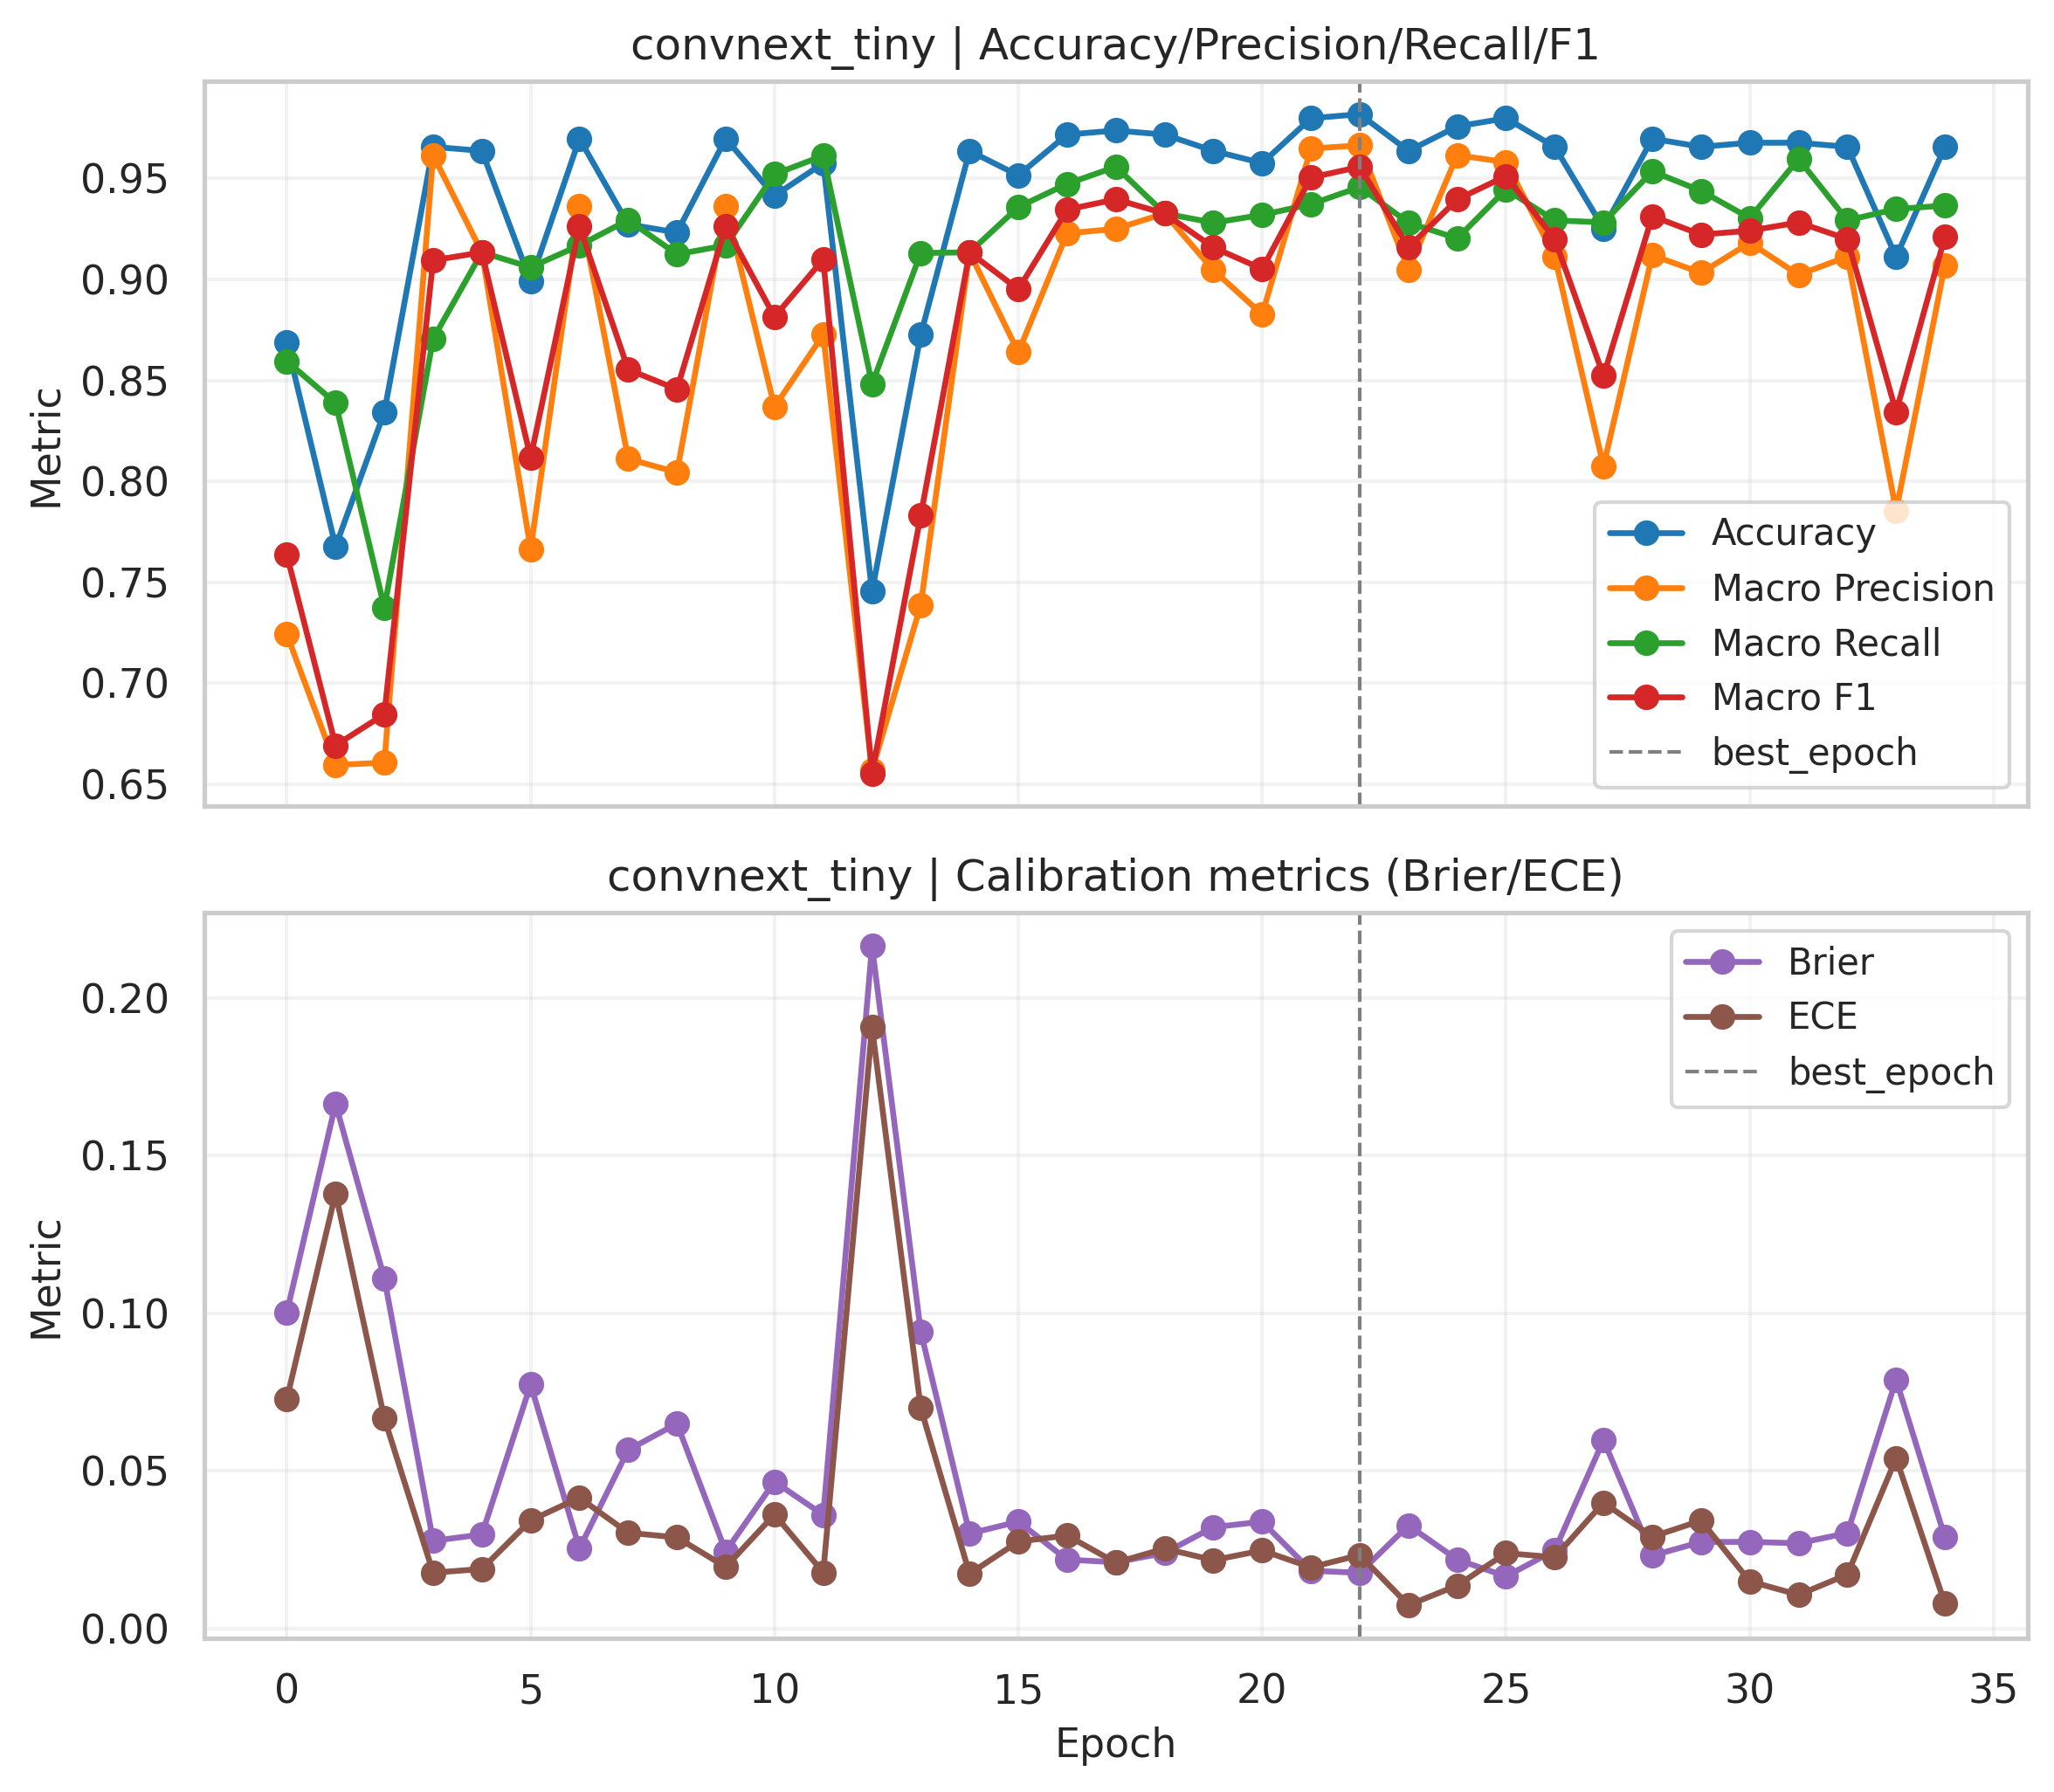

Finished training convnext_tiny -> training_runs/resampled_20251210-214142_convnext_tiny
Best validation macro_f1: 0.9557


In [9]:
# convnext_tiny configuration + training
convnext_tiny_overrides = {**BASE_OVERRIDES, **{'model_name': 'convnext_tiny', 'batch_size': 48, 'lr': 0.0005, 'weight_decay': 5e-05, 'image_size': 256}}
convnext_tiny_run = run_experiment("convnext_tiny", convnext_tiny_overrides)


2025-12-10 22:27:28,612 | INFO | Epoch 000 | train_loss=0.2958 | val_loss=0.2654 | val_f1=0.855
2025-12-10 22:27:55,831 | INFO | Epoch 001 | train_loss=0.2097 | val_loss=0.2397 | val_f1=0.875
2025-12-10 22:28:21,169 | INFO | Epoch 002 | train_loss=0.1819 | val_loss=0.2525 | val_f1=0.844
2025-12-10 22:28:45,838 | INFO | Epoch 003 | train_loss=0.1694 | val_loss=0.6586 | val_f1=0.631
2025-12-10 22:29:10,565 | INFO | Epoch 004 | train_loss=0.1636 | val_loss=0.2380 | val_f1=0.881
2025-12-10 22:29:35,388 | INFO | Epoch 005 | train_loss=0.1618 | val_loss=0.2017 | val_f1=0.905
2025-12-10 22:30:00,163 | INFO | Epoch 006 | train_loss=0.1484 | val_loss=0.1850 | val_f1=0.936
2025-12-10 22:30:25,127 | INFO | Epoch 007 | train_loss=0.1512 | val_loss=0.2360 | val_f1=0.887
2025-12-10 22:30:49,897 | INFO | Epoch 008 | train_loss=0.1495 | val_loss=0.3140 | val_f1=0.802
2025-12-10 22:31:16,068 | INFO | Epoch 009 | train_loss=0.1420 | val_loss=0.2583 | val_f1=0.868
2025-12-10 22:31:40,852 | INFO | Epoch 0

Saved figure to training_runs/resampled_20251210-214142_convnext_small/plots/train_loss_curves.pdf


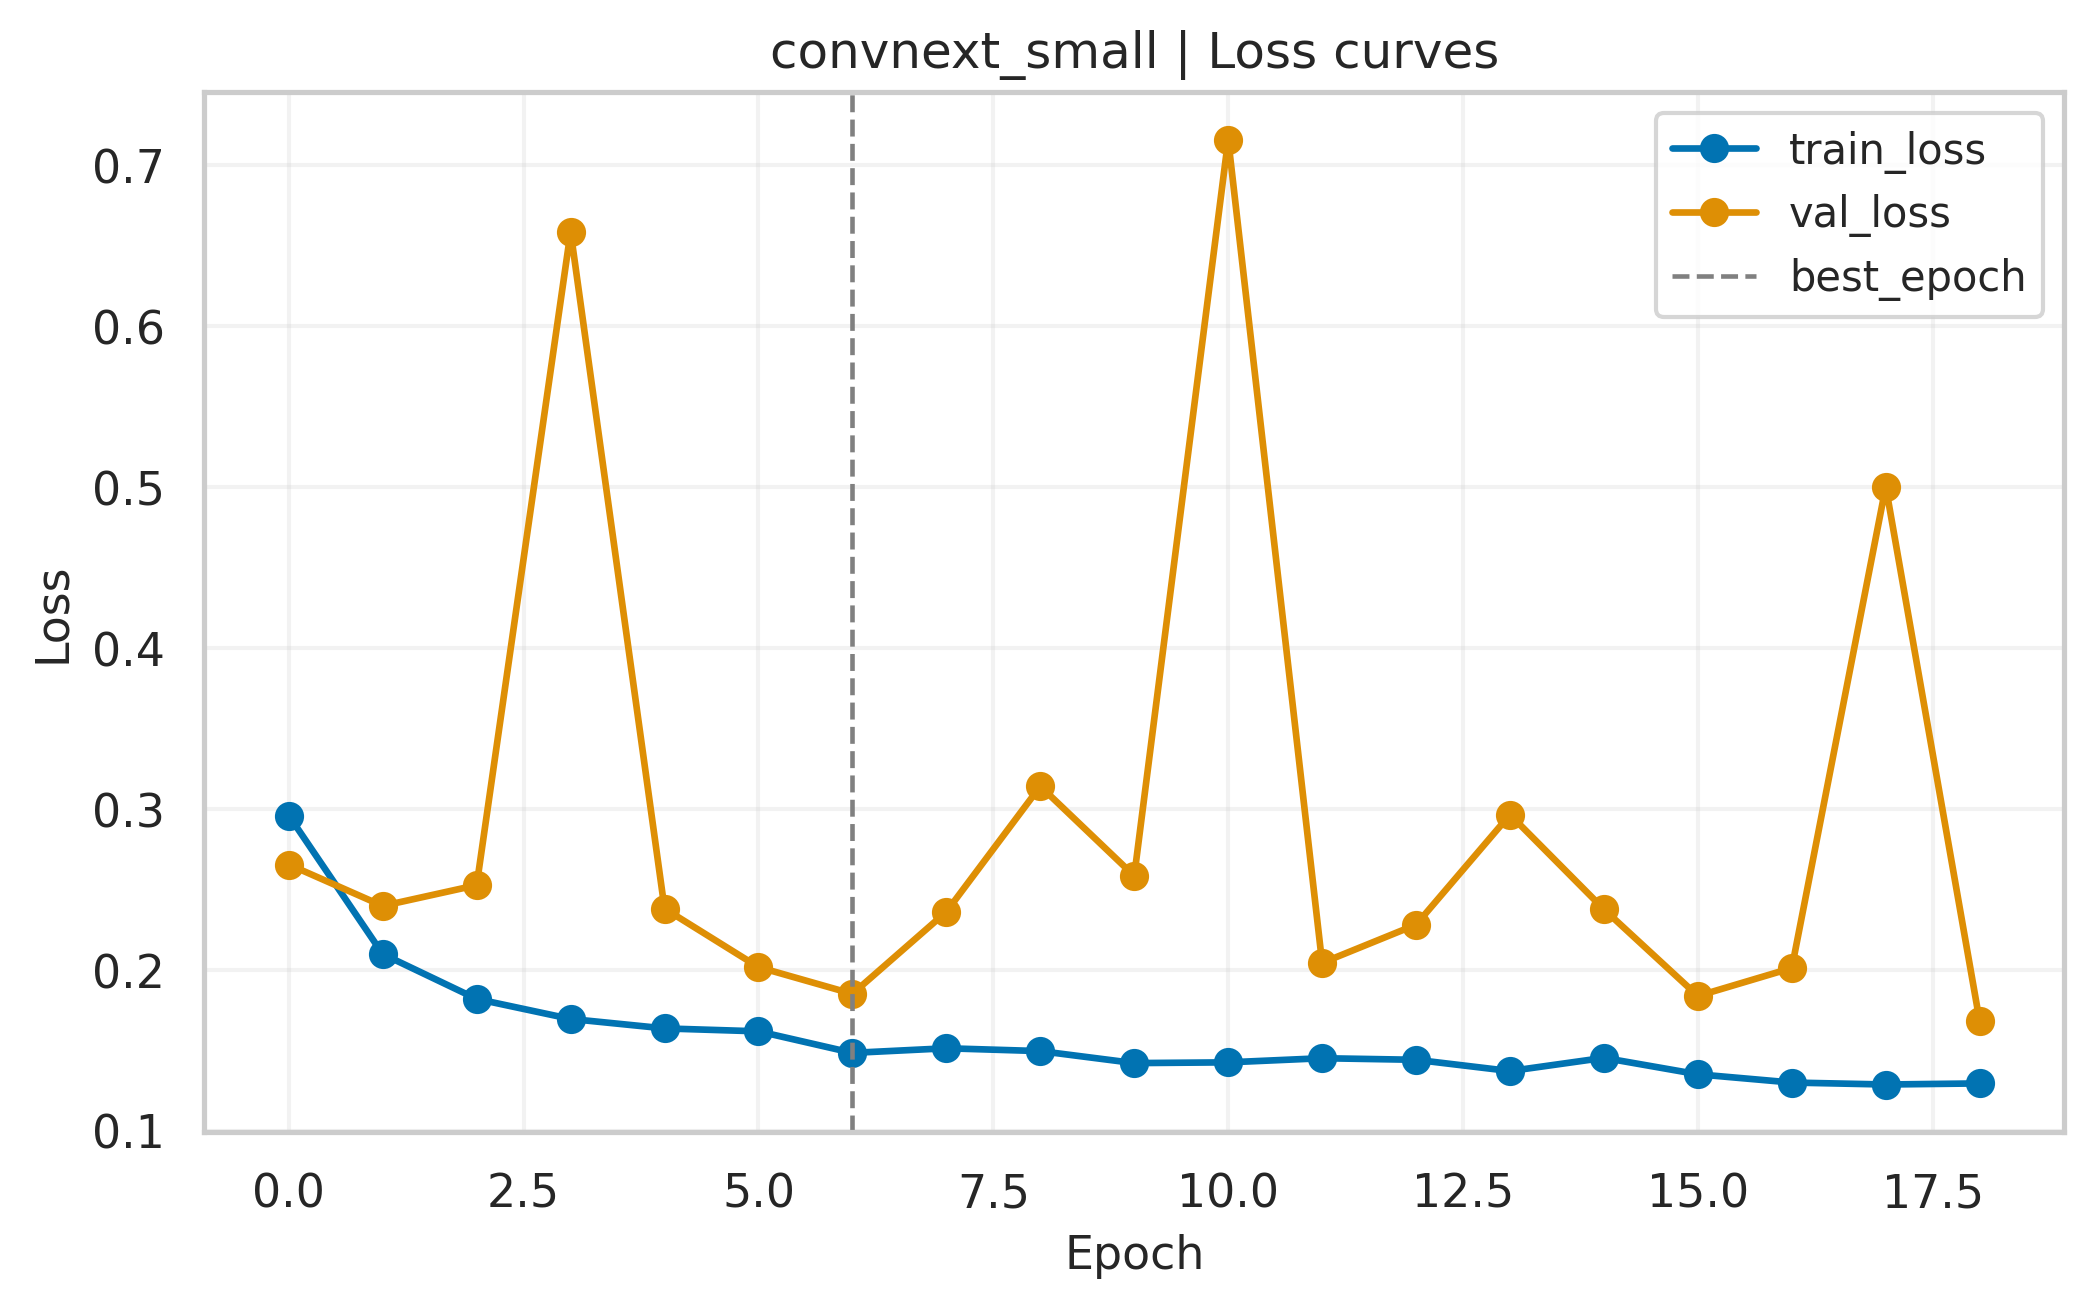

/tmp/ipykernel_98134/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251210-214142_convnext_small/plots/train_metrics.pdf


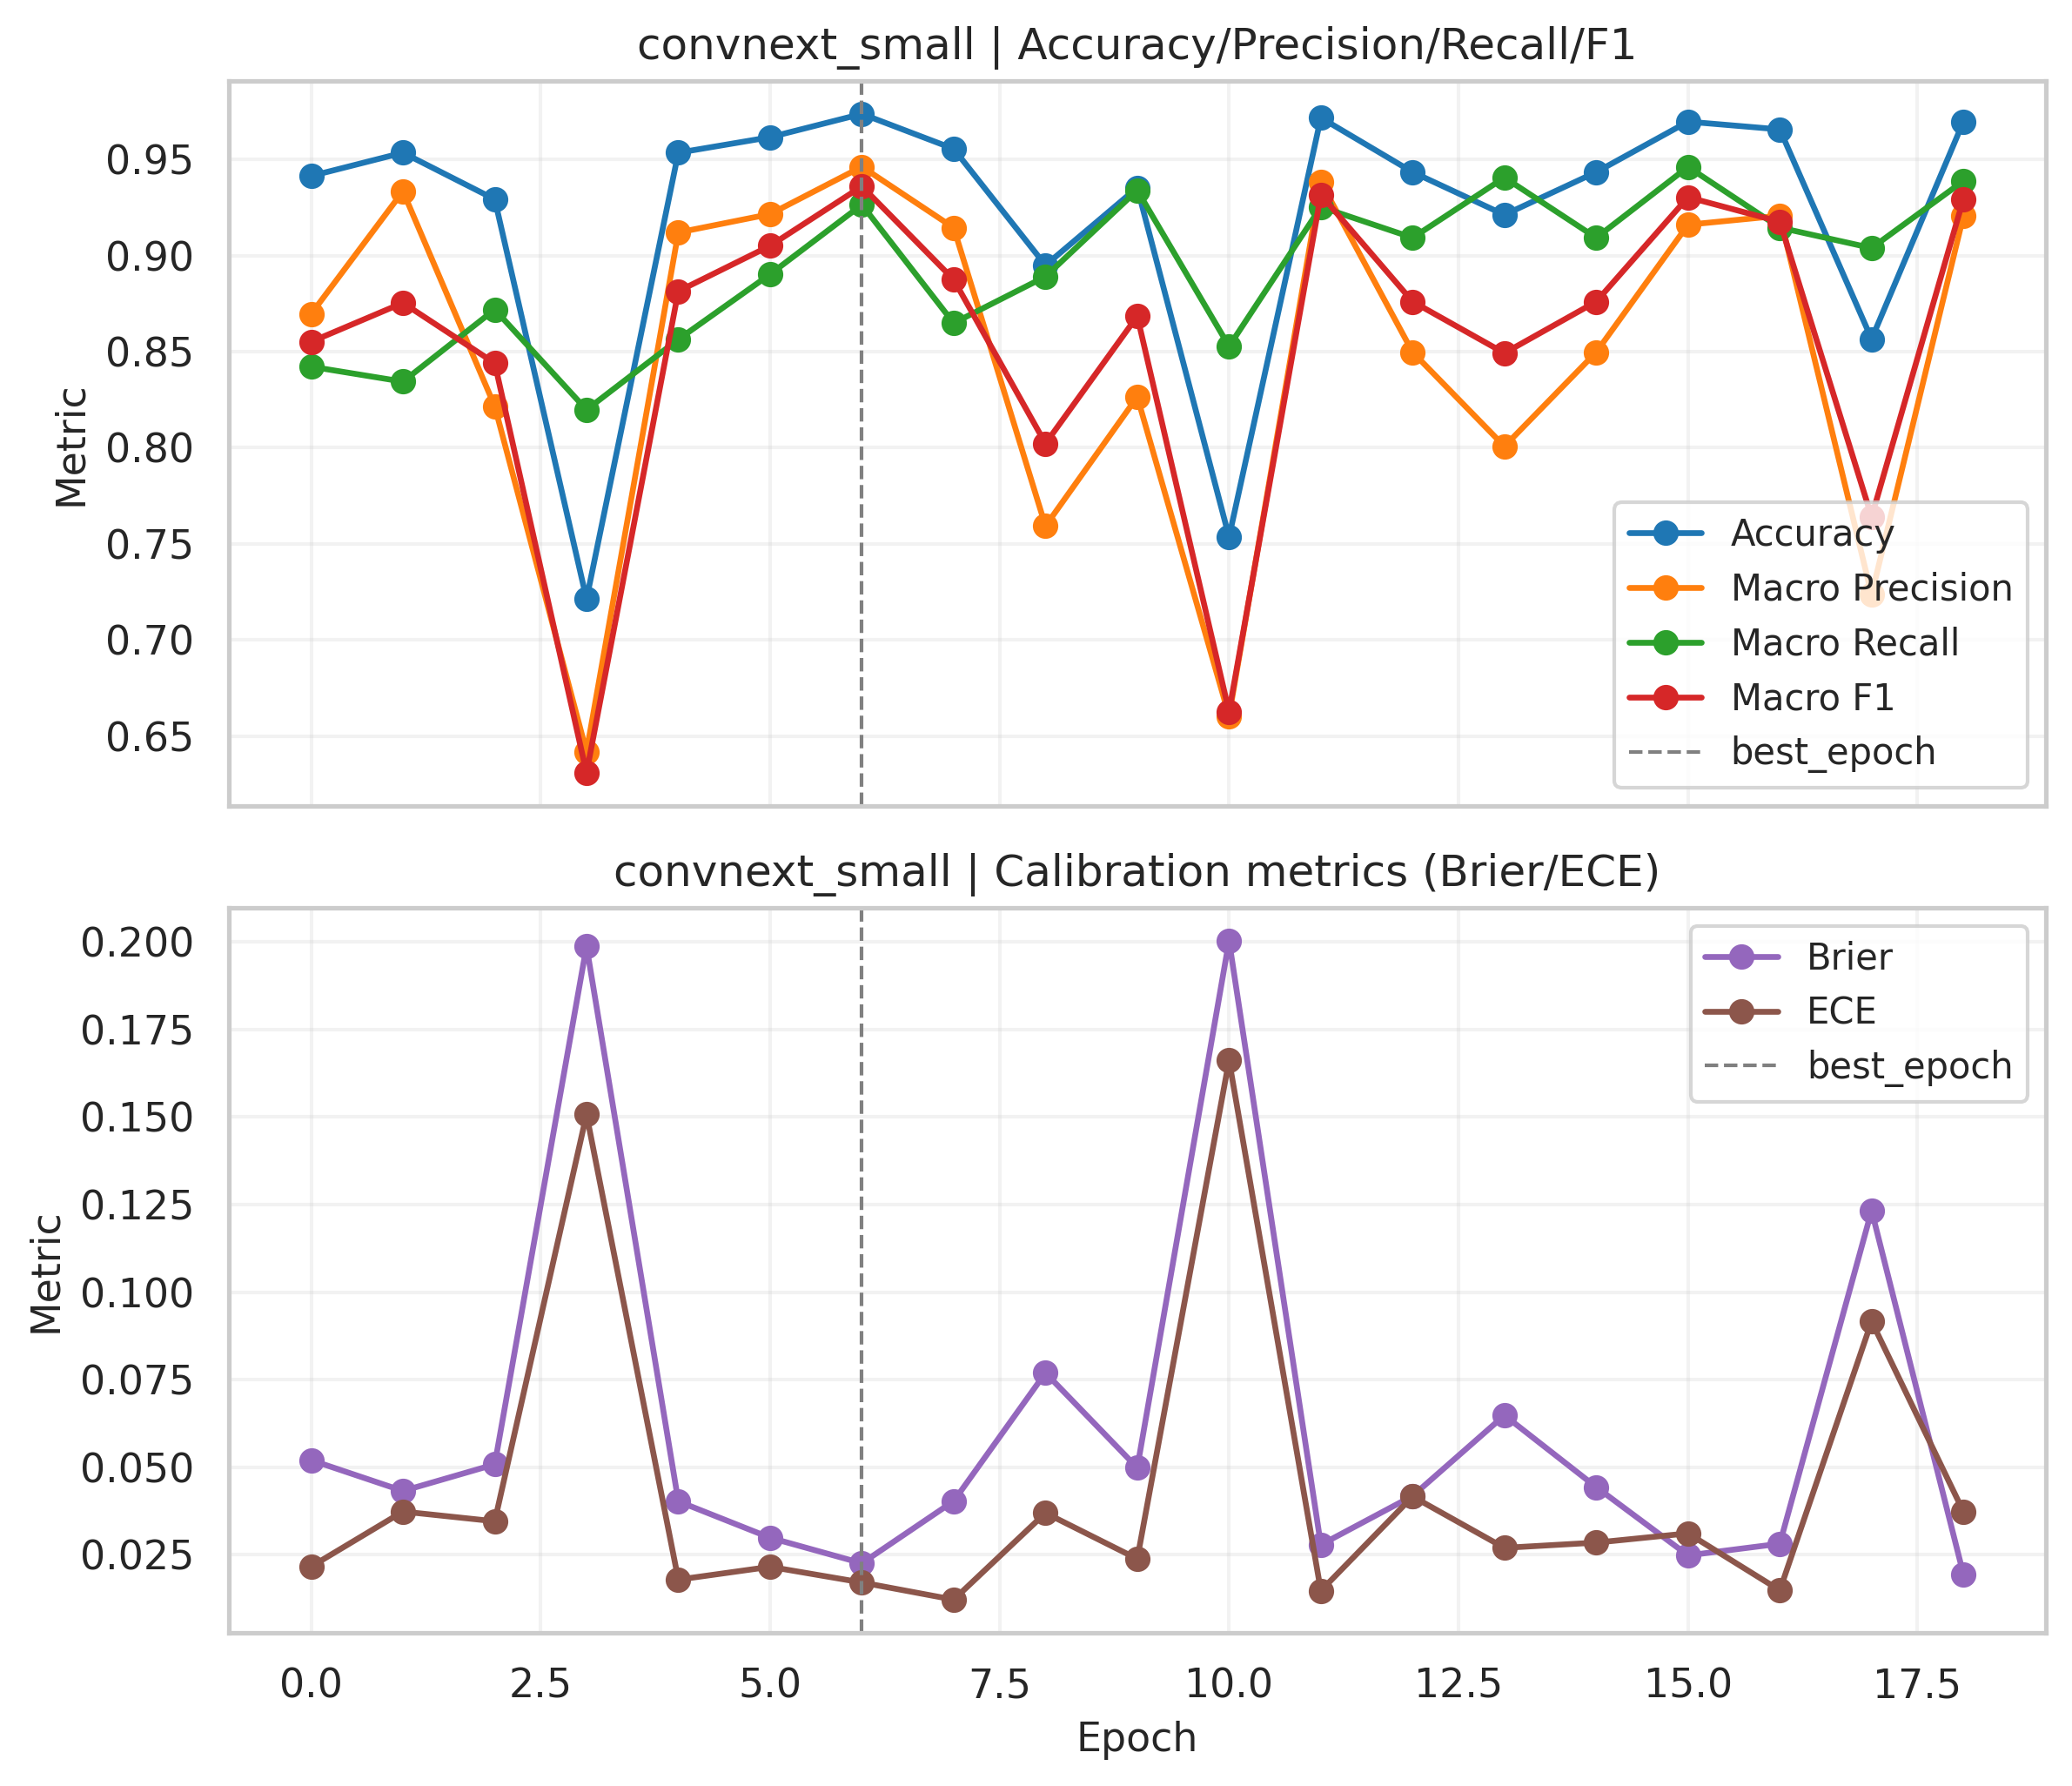

Finished training convnext_small -> training_runs/resampled_20251210-214142_convnext_small
Best validation macro_f1: 0.9360


In [10]:
# convnext_small configuration + training
convnext_small_overrides = {**BASE_OVERRIDES, **{'model_name': 'convnext_small', 'batch_size': 32, 'lr': 0.0005, 'weight_decay': 5e-05, 'image_size': 256}}
convnext_small_run = run_experiment("convnext_small", convnext_small_overrides)


2025-12-11 04:49:03,765 | INFO | Epoch 000 | train_loss=0.3459 | val_loss=0.4609 | val_f1=0.849
2025-12-11 04:49:23,890 | INFO | Epoch 001 | train_loss=0.2720 | val_loss=0.5126 | val_f1=0.811
2025-12-11 04:49:43,597 | INFO | Epoch 002 | train_loss=0.2534 | val_loss=0.4753 | val_f1=0.802
2025-12-11 04:50:03,130 | INFO | Epoch 003 | train_loss=0.2395 | val_loss=0.3696 | val_f1=0.875
2025-12-11 04:50:21,562 | INFO | Epoch 004 | train_loss=0.2299 | val_loss=0.5133 | val_f1=0.732
2025-12-11 04:50:39,644 | INFO | Epoch 005 | train_loss=0.2287 | val_loss=0.3427 | val_f1=0.888
2025-12-11 04:50:59,206 | INFO | Epoch 006 | train_loss=0.2214 | val_loss=0.4733 | val_f1=0.838
2025-12-11 04:51:17,586 | INFO | Epoch 007 | train_loss=0.2200 | val_loss=0.3633 | val_f1=0.883
2025-12-11 04:51:35,757 | INFO | Epoch 008 | train_loss=0.2122 | val_loss=0.3495 | val_f1=0.900
2025-12-11 04:51:55,277 | INFO | Epoch 009 | train_loss=0.2131 | val_loss=0.3335 | val_f1=0.898
2025-12-11 04:52:13,379 | INFO | Epoch 0

Saved figure to training_runs/original_20251211-044753_custom_cnn/plots/train_loss_curves.pdf


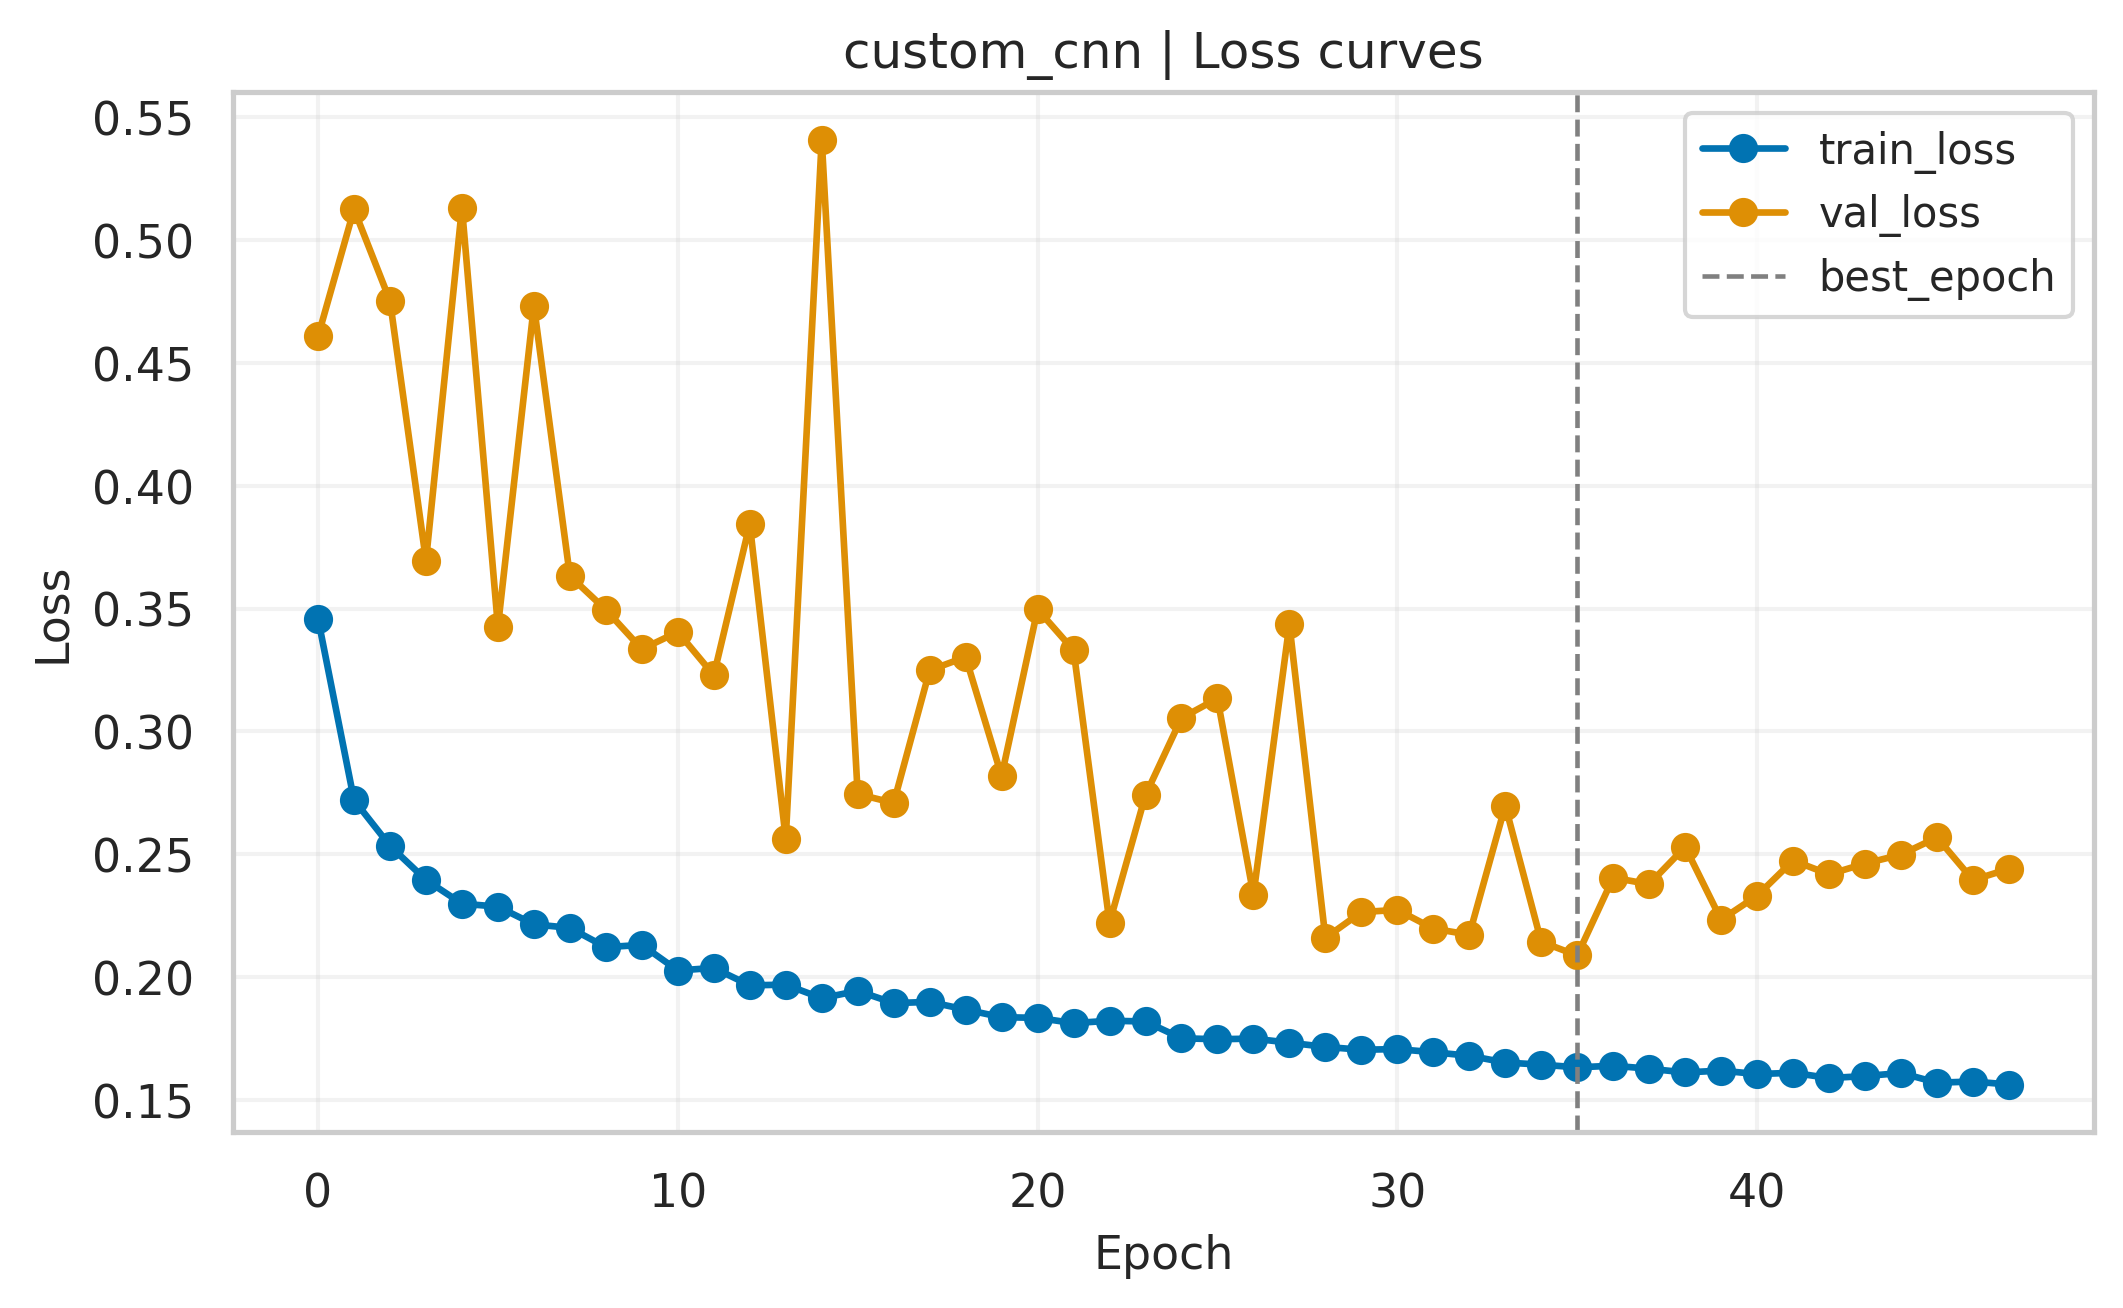

/tmp/ipykernel_1034/1360882262.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/original_20251211-044753_custom_cnn/plots/train_metrics.pdf


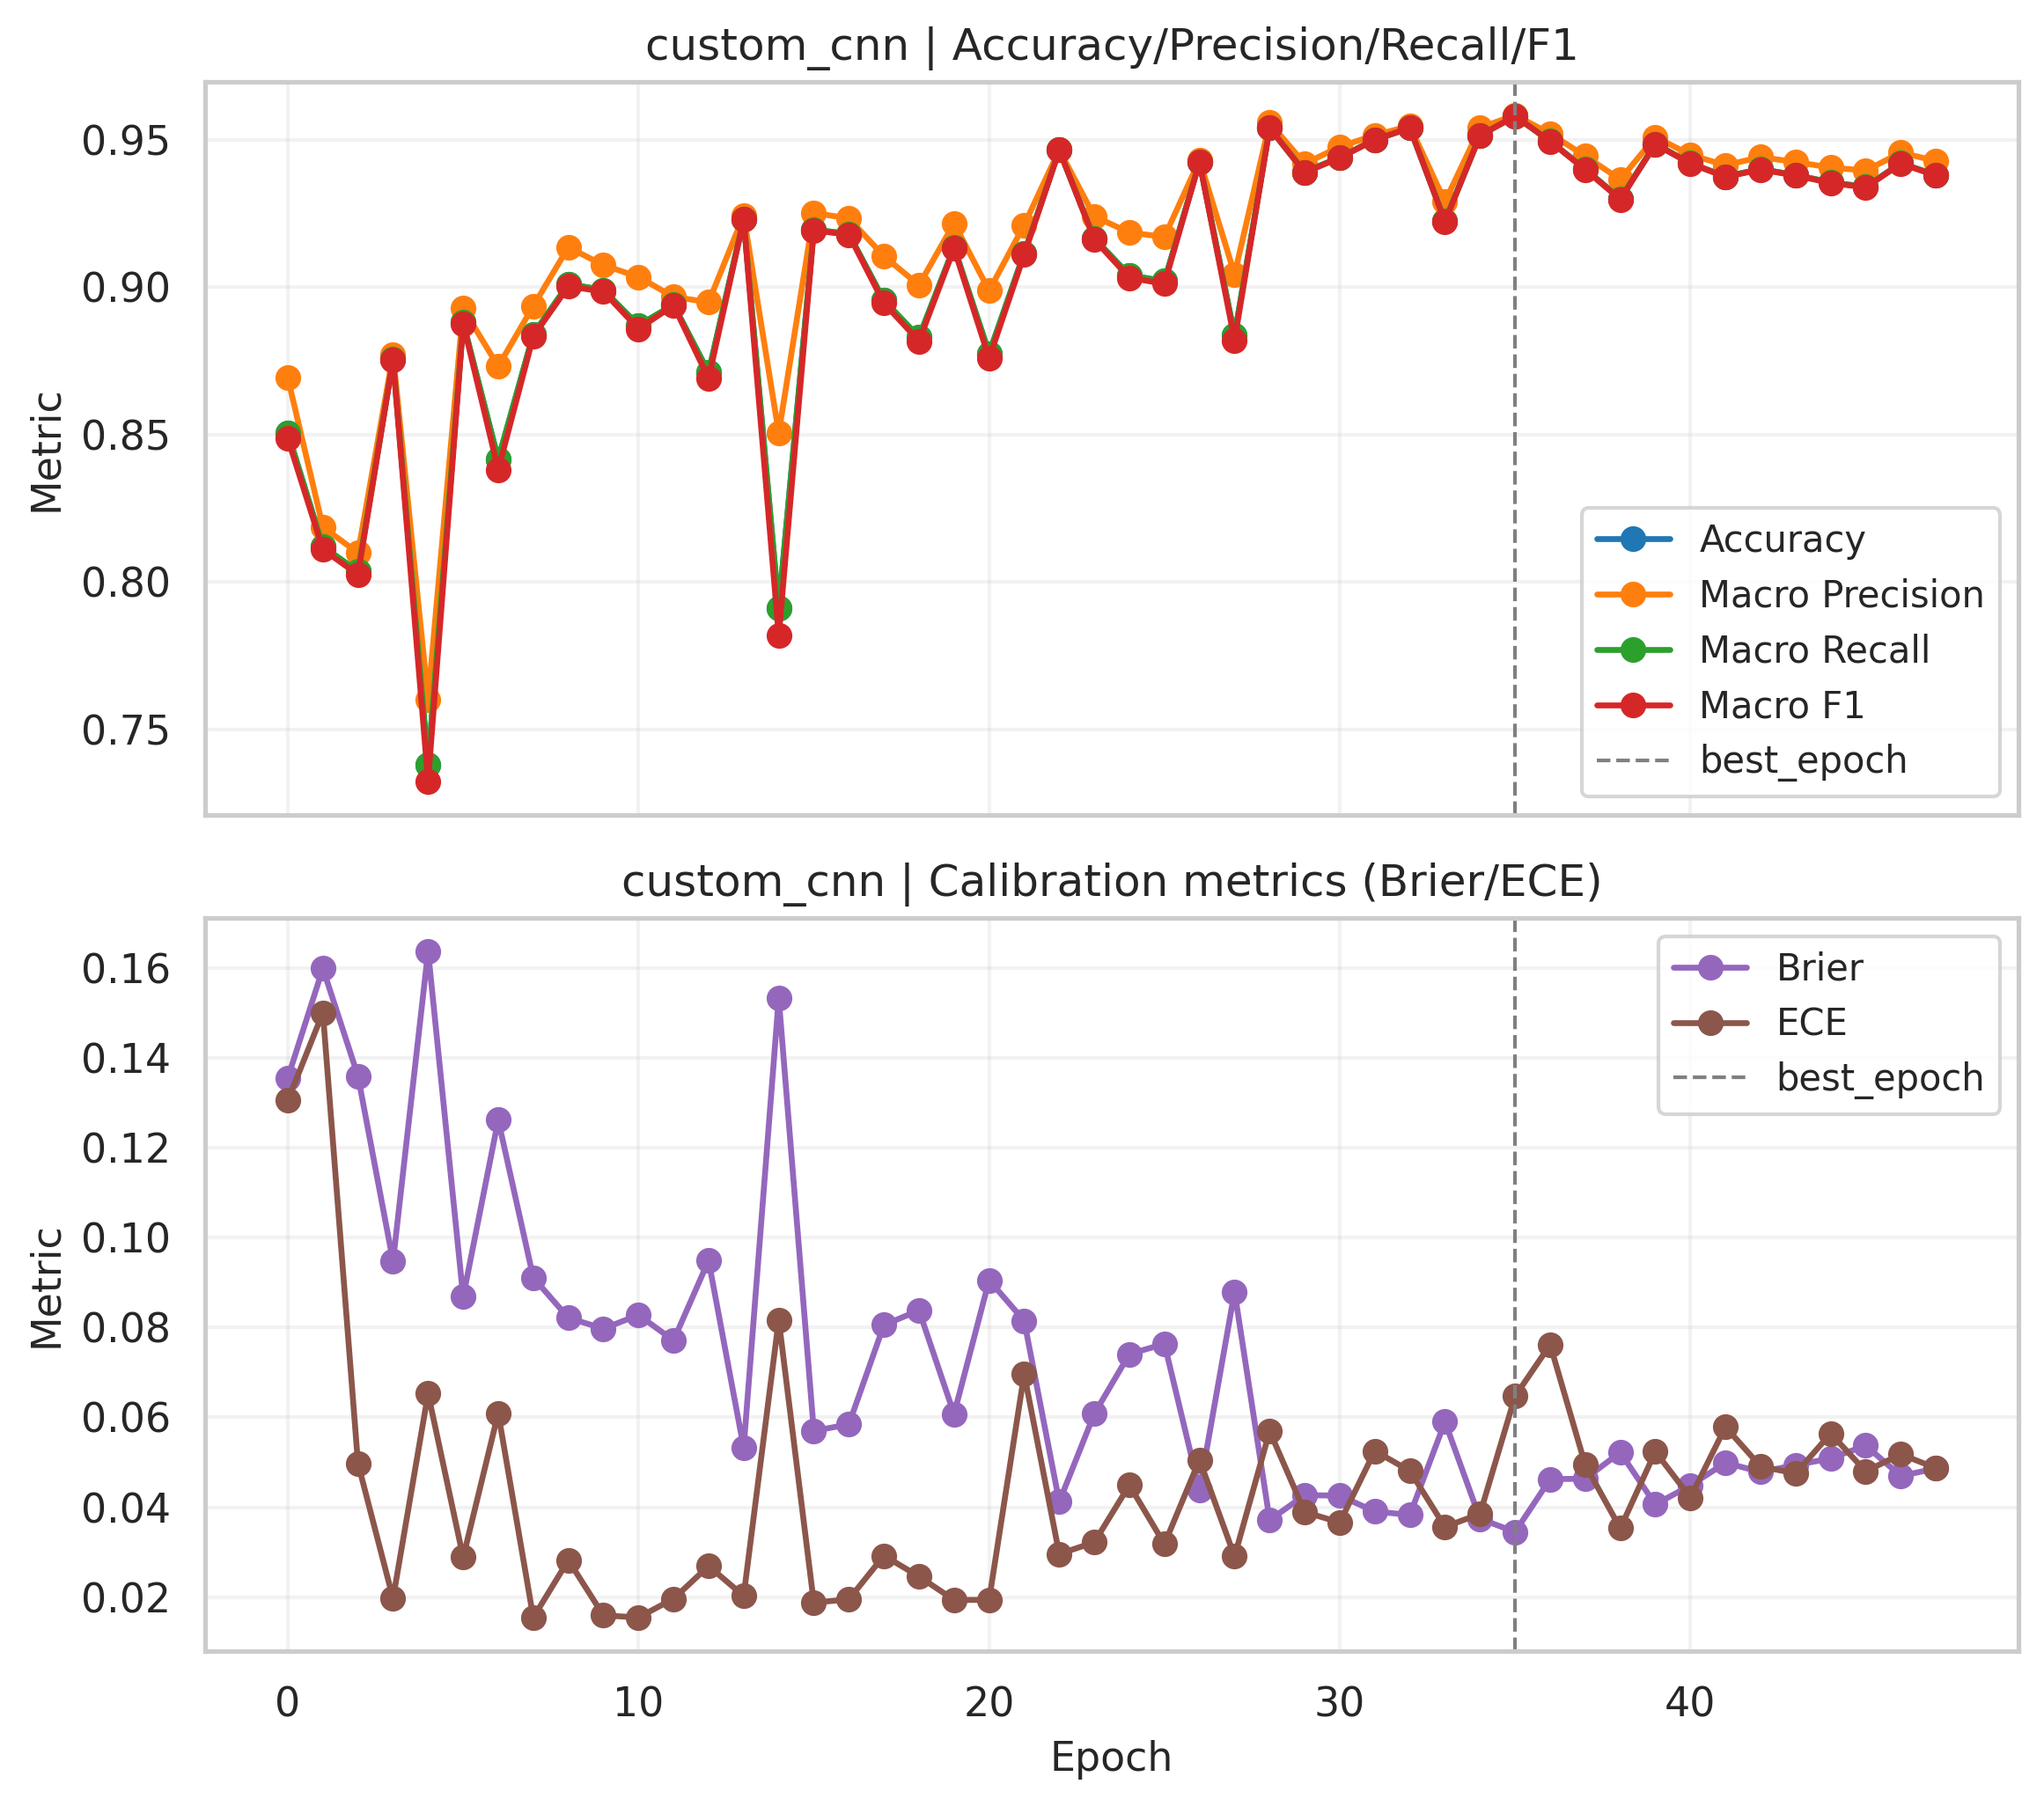

Finished training custom_cnn -> training_runs/original_20251211-044753_custom_cnn
Best validation macro_f1: 0.9580


In [6]:
# custom_cnn configuration + training
custom_cnn_overrides = {**BASE_OVERRIDES, **{'model_name': 'custom_cnn', 'batch_size': 96, 'lr': 0.001, 'dropout': 0.3, 'pretrained': False, 'image_size': 256}}
custom_cnn_run = run_experiment("custom_cnn", custom_cnn_overrides)
